[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter12_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 12: Options and the Volatility Surface

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces the charts and numbers of the main sections of Lecture 12: parity and the binomial tree, Black–Scholes, delta hedging, the smile, Bitcoin options with no-arbitrage checks and density bands, the VIX as an estimator and a forecast, the variance risk premium and its predictive power, and 0DTE options (zero days to expiry). The case study (Back, Crotty & Kazempour, 2022) and the AI-for-discovery example are in the chapter's Quantlets.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_12'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats, optimize, integrate
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

N, n = stats.norm.cdf, stats.norm.pdf

## Style and helpers

In [2]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Course colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
Teal     = '#17A2B8'

HERE = '.'
SEED = 42
BASE = {'S': 100.0, 'K': 100.0, 'T': 0.25, 'r': 0.04, 'sigma': 0.2}
HEDGE = {'S0': 100.0, 'K': 100.0, 'T': 0.25, 'r': 0.04, 'sigma': 0.2, 'mu': 0.08, 'nstep': 252, 'npath': 20000}


def save_fig(name):
    """Save the figure as PDF and transparent PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles, ncol=3, y=0.0):
    """One legend for a multi-panel figure, below the figure."""
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def nw_mean(x, lags):
    """Mean and Newey-West (HAC) standard error of a series."""
    x = np.asarray(x, float)
    m = sm.OLS(x, np.ones_like(x)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return float(m.params[0]), float(m.bse[0])


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    if isinstance(o, pd.Timestamp):
        return str(o)
    return o


import tempfile
# SAVE_TO_DRIVE = True (Colab cell above): charts and tables go to OUT_DIR in Google Drive; otherwise to a temporary folder
KEEP = bool(globals().get('SAVE_TO_DRIVE', False))
HERE = globals().get('OUT_DIR', '.') if KEEP else tempfile.gettempdir()


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE, also save it as PNG in OUT_DIR."""
    if KEEP:
        plt.savefig(os.path.join(HERE, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026: S&P 500 (S&P Dow Jones Indices), SPY open and close (State Street), VIX, VIX9D, VIX3M, VVIX (Cboe), Bitcoin.
- Bitcoin options: all listed contracts on Deribit, snapshot of 22 September 2026; DVOL, Deribit's 30-day implied-volatility index.
- Implied volatility in annualised %.

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# course data: local copy when the notebook runs inside the repository, otherwise read online
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
SNAP_DIR = next((d for d in ('.', '../Quantlets/Ch_12', '../../Quantlets/Ch_12')
                 if os.path.exists(os.path.join(d, 'ch12_deribit_snapshot.csv'))), '.')
END = '2026-09-18'

# name -> (symbol, field, type)
SERIES = {
    'sp500': ('GSPC.INDX', 'close', 'index'),
    'spy':   ('SPY.US', 'adjusted_close', 'etf'),
    'btc':   ('BTC-USD.CC', 'close', 'crypto'),
    'vix':   ('VIX.INDX', 'close', 'vol'),
    'vix9d': ('VIX9D.INDX', 'close', 'vol'),
    'vix3m': ('VIX3M.INDX', 'close', 'vol'),
    'vvix':  ('VVIX.INDX', 'close', 'vol'),
}
DERIBIT = 'https://www.deribit.com/api/v2/public/'
SNAP_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/Quantlets/Ch_12/ch12_deribit_snapshot.csv'


def read_market(symbol):
    """Read the daily series of one symbol from the course data (local copy or online)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def load_close(name, start=None, end=END):
    """Daily price (or index level); except for crypto assets, weekdays only
    (days with an unchanged close are kept: they are real trading days)."""
    symbol, col, kind = SERIES[name]
    s = read_market(symbol)[col].loc[start:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]
    return s.rename(name)


def log_returns(name, start=None, end=END):
    """Log returns on the series' own calendar."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


def spy_open_close(start=None, end=END):
    """Daily SPY open and close (unadjusted prices: the same-day ratio does not depend on adjustments)."""
    d = read_market('SPY.US').loc[start:end, ['open', 'close']]
    d = d[(d > 0).all(axis=1)]
    return d[d.index.dayofweek < 5]


def _get(method, **params):
    url = DERIBIT + method + '?' + '&'.join(f'{k}={v}' for k, v in params.items())
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    return json.load(urllib.request.urlopen(req, timeout=60))['result']


def deribit_chain(path=None, refresh=False):
    """BTC option chain (mark prices, implied volatilities) at the snapshot time."""
    path = path or os.path.join(SNAP_DIR, 'ch12_deribit_snapshot.csv')
    if not refresh:
        for src in (path, SNAP_RAW):
            try:
                return pd.read_csv(src, parse_dates=['snapshot_utc', 'expiry'])
            except Exception:
                pass
    rows = _get('get_book_summary_by_currency', currency='BTC', kind='option')
    t0 = pd.Timestamp.now(tz='UTC').floor('min').tz_localize(None)
    out = []
    for x in rows:
        _, exp, strike, cp = x['instrument_name'].split('-')
        out.append(dict(snapshot_utc=t0, instrument=x['instrument_name'],
                        expiry=pd.to_datetime(exp, format='%d%b%y') + pd.Timedelta(hours=8),
                        strike=float(strike), type='call' if cp == 'C' else 'put',
                        mark_iv=x['mark_iv'], mark_price=x['mark_price'], bid=x['bid_price'], ask=x['ask_price'],
                        forward=x['underlying_price'], index=x['estimated_delivery_price'],
                        open_interest=x['open_interest'], volume_usd=x['volume_usd']))
    d = pd.DataFrame(out).sort_values(['expiry', 'strike', 'type']).reset_index(drop=True)
    d.to_csv(path, index=False)
    return d


def dvol_history(start='2021-03-24', end=END):
    """DVOL index (30-day implied volatility of BTC options, annualised, in %), daily values."""
    t1 = int(pd.Timestamp(end).tz_localize('UTC').timestamp() * 1000) + 86_400_000
    t0 = int(pd.Timestamp(start).tz_localize('UTC').timestamp() * 1000)
    data = []
    while True:
        r = _get('get_volatility_index_data', currency='BTC', start_timestamp=t0, end_timestamp=t1, resolution='1D')
        data += r['data']
        if not r.get('continuation') or r['continuation'] <= t0:
            break
        t1 = r['continuation']
    d = pd.DataFrame(data, columns=['t', 'open', 'high', 'low', 'close']).drop_duplicates('t')
    d.index = pd.to_datetime(d['t'], unit='ms').dt.normalize()
    return d.sort_index()['close'].loc[start:end].rename('dvol')

## Option pricing tools

- `bs_price`, `bs_greeks`: Black–Scholes and the Greeks; `implied_vol`, `newton_iv`: implied volatility.
- `crr_price`: Cox–Ross–Rubinstein tree; `merton_price`, `heston_price`: jump and stochastic-volatility models.
- `svi_w`, `svi_fit`: SVI smile; `variance_from_strip`: implied variance (VIX formula); `delta_hedge`: discrete delta hedging.

In [4]:
def bs_price(S, K, T, r, sigma, kind='call', q=0.0):
    """Black-Scholes price of a European option."""
    S, K, T, sigma = map(np.asarray, (S, K, T, sigma))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == 'call':
        return S * np.exp(-q * T) * N(d1) - K * np.exp(-r * T) * N(d2)
    return K * np.exp(-r * T) * N(-d2) - S * np.exp(-q * T) * N(-d1)


def bs_greeks(S, K, T, r, sigma, kind='call', q=0.0):
    """Delta, gamma, vega (per volatility point), theta (per calendar day), rho; plus d1, d2."""
    S, K, T, sigma = map(np.asarray, (S, K, T, sigma))
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    gamma = np.exp(-q * T) * n(d1) / (S * sigma * np.sqrt(T))
    vega = S * np.exp(-q * T) * n(d1) * np.sqrt(T) / 100
    common = -S * np.exp(-q * T) * n(d1) * sigma / (2 * np.sqrt(T))
    if kind == 'call':
        delta = np.exp(-q * T) * N(d1)
        theta = common - r * K * np.exp(-r * T) * N(d2) + q * S * np.exp(-q * T) * N(d1)
        rho = K * T * np.exp(-r * T) * N(d2) / 100
    else:
        delta = -np.exp(-q * T) * N(-d1)
        theta = common + r * K * np.exp(-r * T) * N(-d2) - q * S * np.exp(-q * T) * N(-d1)
        rho = -K * T * np.exp(-r * T) * N(-d2) / 100
    return dict(d1=d1, d2=d2, delta=delta, gamma=gamma, vega=vega, theta=theta / 365, rho=rho)


def implied_vol(price, S, K, T, r, kind='call', q=0.0, lo=1e-4, hi=5.0):
    """Implied volatility: the unique solution of BS(sigma) = price (vega > 0)."""
    f = lambda s: bs_price(S, K, T, r, s, kind, q) - price
    if f(lo) > 0 or f(hi) < 0:
        return np.nan
    return optimize.brentq(f, lo, hi, xtol=1e-10)


def newton_iv(price, S, K, T, r, sigma0=0.2, kind='call', steps=4):
    """Newton steps: sigma_{k+1} = sigma_k - (BS(sigma_k) - price) / vega(sigma_k)."""
    out, s = [], sigma0
    for _ in range(steps):
        p = float(bs_price(S, K, T, r, s, kind))
        v = float(bs_greeks(S, K, T, r, s, kind)['vega']) * 100
        s_new = s - (p - price) / v
        out.append(dict(sigma=s, price=p, vega=v, sigma_next=s_new))
        s = s_new
    return out


def crr_price(S, K, T, r, sigma, steps, kind='call', american=False):
    """Cox-Ross-Rubinstein binomial tree: u = exp(sigma sqrt(dt)), d = 1/u, p = (e^{r dt} - d)/(u - d)."""
    dt = T / steps
    u = np.exp(sigma * np.sqrt(dt)); d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)
    j = np.arange(steps + 1)
    ST = S * u ** (steps - j) * d ** j
    V = np.maximum(ST - K, 0) if kind == 'call' else np.maximum(K - ST, 0)
    for i in range(steps - 1, -1, -1):
        V = disc * (p * V[:-1] + (1 - p) * V[1:])
        if american:
            Si = S * u ** (i - np.arange(i + 1)) * d ** np.arange(i + 1)
            V = np.maximum(V, (Si - K) if kind == 'call' else (K - Si))
    return float(V[0])


def merton_price(S, K, T, r, sigma, lam, mu_j, sig_j, kind='call', nmax=60):
    """Merton (1976): log-normal jumps ln(1+J) ~ N(mu_j, sig_j^2), intensity lam; Poisson series of BS prices."""
    kappa = np.exp(mu_j + 0.5 * sig_j ** 2) - 1
    lam2 = lam * (1 + kappa)
    tot = 0.0
    for k in range(nmax):
        s_k = np.sqrt(sigma ** 2 + k * sig_j ** 2 / T)
        r_k = r - lam * kappa + k * np.log(1 + kappa) / T
        w = stats.poisson.pmf(k, lam2 * T)
        tot = tot + w * bs_price(S, K, T, r_k, s_k, kind)
    return tot


def heston_price(S, K, T, r, v0, kappa, theta, xi, rho, kind='call'):
    """Heston (1993): call price by the Lewis (2001) formula, with the characteristic function of ln(S_T/F) (stable form)."""
    def phi(u):
        d = np.sqrt((rho * xi * 1j * u - kappa) ** 2 + xi ** 2 * (1j * u + u ** 2))
        g = (kappa - rho * xi * 1j * u - d) / (kappa - rho * xi * 1j * u + d)
        e = np.exp(-d * T)
        C = kappa * theta / xi ** 2 * ((kappa - rho * xi * 1j * u - d) * T - 2 * np.log((1 - g * e) / (1 - g)))
        D = (kappa - rho * xi * 1j * u - d) / xi ** 2 * (1 - e) / (1 - g * e)
        return np.exp(C + D * v0)
    x = np.log(S / K) + r * T
    f = lambda u: (np.exp(1j * u * x) * phi(u - 0.5j)).real / (u ** 2 + 0.25)
    call = S - np.sqrt(S * K) * np.exp(-r * T / 2) / np.pi * integrate.quad(f, 0, 200, limit=500, epsabs=1e-12)[0]
    return call if kind == 'call' else call - S + K * np.exp(-r * T)


def svi_w(k, a, b, rho, m, s):
    """SVI (Gatheral): total implied variance w(k) = a + b (rho (k - m) + sqrt((k - m)^2 + s^2)), k = ln(K/F)."""
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + s ** 2))


def svi_fit(k, w, weights=None):
    """SVI fit by (weighted) least squares, with constraints b >= 0, |rho| < 1, s > 0."""
    k, w = np.asarray(k), np.asarray(w)
    wt = np.ones_like(w) if weights is None else np.asarray(weights)
    def loss(p):
        return np.sum(wt * (svi_w(k, *p) - w) ** 2)
    best = None
    for rho0 in (-0.5, 0.0, 0.3):
        for s0 in (0.05, 0.2):
            x0 = [max(w.min() * 0.5, 1e-4), 0.1, rho0, 0.0, s0]
            res = optimize.minimize(loss, x0, method='L-BFGS-B',
                                    bounds=[(-1, 5), (1e-6, 10), (-0.999, 0.999), (-2, 2), (1e-4, 3)])
            if best is None or res.fun < best.fun:
                best = res
    a, b, rho, m, s = best.x
    return dict(a=a, b=b, rho=rho, m=m, s=s, rmse=np.sqrt(best.fun / wt.sum()),
                wmin=a + b * s * np.sqrt(1 - rho ** 2))


def variance_from_strip(K, Q, F, T, r=0.0):
    """Implied variance (VIX formula): 2/T sum dK/K^2 e^{rT} Q(K) - 1/T (F/K0 - 1)^2, Q = OTM price (mid)."""
    K, Q = np.asarray(K, float), np.asarray(Q, float)
    o = np.argsort(K); K, Q = K[o], Q[o]
    dK = np.empty_like(K)
    dK[1:-1] = (K[2:] - K[:-2]) / 2
    dK[0], dK[-1] = K[1] - K[0], K[-1] - K[-2]
    K0 = K[K <= F].max()
    return 2 / T * np.sum(dK / K ** 2 * np.exp(r * T) * Q) - (F / K0 - 1) ** 2 / T


def delta_hedge(paths, K, T, r, sigma_imp, n_rebal, kind='call'):
    """Sell an option at BS(sigma_imp) and delta-hedge it n_rebal times until expiry.
    paths: price matrix (n_paths, n_steps+1) on a uniform grid; n_steps divisible by n_rebal.
    Returns the hedging error at expiry (hedge portfolio value minus the option pay-off)."""
    npath, nstep = paths.shape[0], paths.shape[1] - 1
    every = nstep // n_rebal
    dt = T / nstep
    S0 = paths[:, 0]
    V0 = bs_price(S0, K, T, r, sigma_imp, kind)
    delta = bs_greeks(S0, K, T, r, sigma_imp, kind)['delta']
    cash = V0 - delta * S0
    for i in range(1, nstep + 1):
        cash = cash * np.exp(r * dt)
        if i % every == 0 and i < nstep:
            tau = T - i * dt
            d_new = bs_greeks(paths[:, i], K, tau, r, sigma_imp, kind)['delta']
            cash -= (d_new - delta) * paths[:, i]
            delta = d_new
    ST = paths[:, -1]
    payoff = np.maximum(ST - K, 0) if kind == 'call' else np.maximum(K - ST, 0)
    return cash + delta * ST - payoff

## 1. Put–call parity: a numerical check

In [5]:
def parity_example():
    """Put-call parity for S = K = 100, T = 6 months, r = 4%, sigma = 20%."""
    S, K, T, r, s = 100.0, 100.0, 0.5, 0.04, 0.20
    C = float(bs_price(S, K, T, r, s, 'call')); P = float(bs_price(S, K, T, r, s, 'put'))
    return dict(C=C, P=P, pv_k=K * np.exp(-r * T), lhs=C - P, rhs=S - K * np.exp(-r * T))


parity_example()

{'C': 6.627078013614728,
 'P': 4.646945344290259,
 'pv_k': np.float64(98.01986733067552),
 'lhs': 1.980132669324469,
 'rhs': np.float64(1.980132669324476)}

## 2. The binomial tree

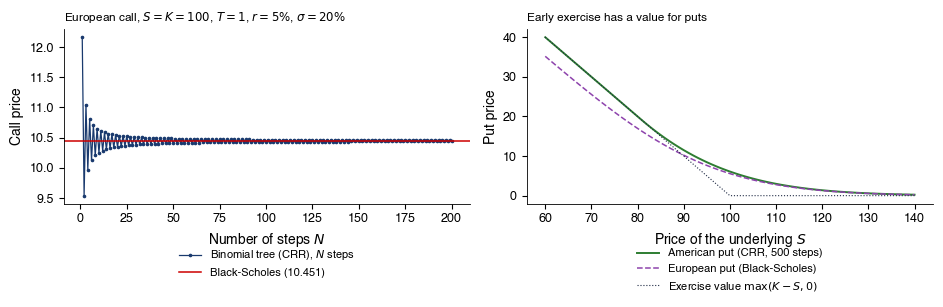

{'bs': 10.450583572185565,
 'crr10': 10.25340904487193,
 'crr11': 10.61120009587546,
 'crr50': 10.410691540732644,
 'crr200': 10.44059125985994,
 'crr1000': 10.448584103764572,
 'am_put': 6.089989952552339,
 'eu_put': 5.573526022256971,
 'eep': 0.5164639302953686}

In [6]:
def fig_binomial():
    """Convergence of the CRR tree to Black-Scholes; American vs European put."""
    S, K, T, r, s = 100.0, 100.0, 1.0, 0.05, 0.20
    bs = float(bs_price(S, K, T, r, s, 'call'))
    Ns = np.arange(1, 201)
    crr = np.array([crr_price(S, K, T, r, s, k) for k in Ns])
    Sg = np.linspace(60, 140, 81)
    am = np.array([crr_price(x, K, T, r, s, 500, 'put', True) for x in Sg])
    eu = bs_price(Sg, K, T, r, s, 'put')
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.3))
    ax = axes[0]
    ax.plot(Ns, crr, color=MainBlue, lw=0.9, marker='o', ms=1.6, label='Binomial tree (CRR), $N$ steps')
    ax.axhline(bs, color=IDAred, lw=1.1, label=f'Black-Scholes ({bs:.3f})')
    ax.set_xlabel('Number of steps $N$'); ax.set_ylabel('Call price')
    ax.set_title('European call, $S = K = 100$, $T = 1$, $r = 5\\%$, $\\sigma = 20\\%$', fontsize=8.5, loc='left')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    ax = axes[1]
    ax.plot(Sg, am, color=Forest, lw=1.4, label='American put (CRR, 500 steps)')
    ax.plot(Sg, eu, color=Purple, lw=1.1, ls='--', label='European put (Black-Scholes)')
    ax.plot(Sg, np.maximum(K - Sg, 0), color=Gray, lw=0.8, ls=':', label='Exercise value $\\max(K - S, 0)$')
    ax.set_xlabel('Price of the underlying $S$'); ax.set_ylabel('Put price')
    ax.set_title('Early exercise has a value for puts', fontsize=8.5, loc='left')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    plt.tight_layout()
    save_fig('ch12_binomial')
    am100 = crr_price(S, K, T, r, s, 2000, 'put', True)
    eu100 = float(bs_price(S, K, T, r, s, 'put'))
    return dict(bs=bs, crr10=crr_price(S, K, T, r, s, 10), crr11=crr_price(S, K, T, r, s, 11),
                crr50=crr_price(S, K, T, r, s, 50), crr200=crr_price(S, K, T, r, s, 200),
                crr1000=crr_price(S, K, T, r, s, 1000), am_put=am100, eu_put=eu100, eep=am100 - eu100)


fig_binomial()

## 3. Black–Scholes and the Greeks

- Worked example: $S = 100$, $K = 105$, three months, $r = 4\%$, $\sigma = 16\%$.

In [7]:
def bs_example():
    """Worked example: S = 100, K = 105, T = 3 months, r = 4%, sigma = 16%."""
    S, K, T, r, s = 100.0, 105.0, 0.25, 0.04, 0.16
    g = bs_greeks(S, K, T, r, s, 'call')
    gp = bs_greeks(S, K, T, r, s, 'put')
    return dict(d1=float(g['d1']), d2=float(g['d2']), Nd1=float(stats.norm.cdf(g['d1'])), Nd2=float(stats.norm.cdf(g['d2'])),
                call=float(bs_price(S, K, T, r, s, 'call')), put=float(bs_price(S, K, T, r, s, 'put')),
                pvk=K * np.exp(-r * T), delta=float(g['delta']), gamma=float(g['gamma']), vega=float(g['vega']),
                theta=float(g['theta']), rho=float(g['rho']), delta_put=float(gp['delta']), theta_put=float(gp['theta']))


bs_example()

{'d1': -0.44487705211790074,
 'd2': -0.5248770521179007,
 'Nd1': 0.3282043035947882,
 'Nd2': 0.2998343314740254,
 'call': 1.6510827065228817,
 'put': 5.606315250185531,
 'pvk': np.float64(103.95523254366265),
 'delta': 0.3282043035947882,
 'gamma': 0.04516928897019714,
 'vega': 0.18067715588078856,
 'theta': -0.019256007929598553,
 'rho': 0.07792336913238984,
 'delta_put': -0.6717956964052119,
 'theta_put': -0.00786365367823826}

## 4. Delta hedging

- Geometric Brownian motion with $\mu = 8\%$, $\sigma = 20\%$; sold three-month ATM call.

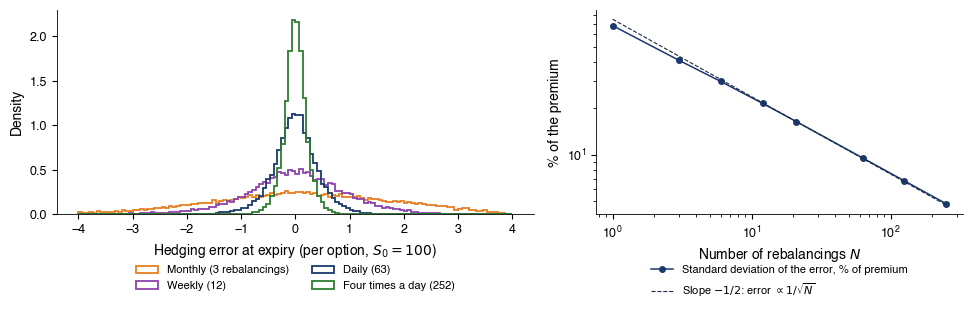

{'premium': 4.485236409022086,
 'slope': -0.48363877947977557,
 'sd': {'1': 3.060956215028111,
  '3': 1.8277590357090703,
  '6': 1.3337445418454645,
  '12': 0.9631537877351187,
  '21': 0.7344001055515947,
  '63': 0.42791054727276073,
  '126': 0.3038014317673876,
  '252': 0.21650400216999996},
 'sdpct': {'1': 68.24514776681502,
  '3': 40.75056182172515,
  '6': 29.736326476852536,
  '12': 21.473868931361743,
  '21': 16.373721217333014,
  '63': 9.540423474936919,
  '126': 6.773364970379014,
  '252': 4.827036580156635},
 'mean': {'1': -0.04941653524755539,
  '3': 0.0017040060904564668,
  '6': 0.0005891542378018712,
  '12': -0.0004988722976864934,
  '21': -0.00033889433352110707,
  '63': -0.004155281244763441,
  '126': -0.0010388002705417807,
  '252': 0.000788967464459755},
 'q01_63': -1.1746271205373136,
 'q01_12': -2.678179026263708}

In [8]:
def gbm_paths(S0, mu, sigma, T, nstep, npath, seed=SEED):
    rng = np.random.default_rng(seed)
    dt = T / nstep
    z = rng.standard_normal((npath, nstep))
    x = np.cumsum((mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * z, axis=1)
    return S0 * np.exp(np.hstack([np.zeros((npath, 1)), x]))


def hedge_errors():
    """Hedging error for several rebalancing frequencies (20,000 GBM paths)."""
    h = HEDGE
    paths = gbm_paths(h['S0'], h['mu'], h['sigma'], h['T'], h['nstep'], h['npath'])
    prem = float(bs_price(h['S0'], h['K'], h['T'], h['r'], h['sigma']))
    out = {}
    for nr in [1, 3, 6, 12, 21, 63, 126, 252]:
        e = delta_hedge(paths, h['K'], h['T'], h['r'], h['sigma'], nr)
        out[nr] = e
    return out, prem


def fig_hedge_error(errs, prem):
    labels = {3: 'Monthly (3 rebalancings)', 12: 'Weekly (12)', 63: 'Daily (63)', 252: 'Four times a day (252)'}
    cols = {3: Orange, 12: Purple, 63: MainBlue, 252: Forest}
    fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.3), gridspec_kw={'width_ratios': [1.3, 1]})
    ax = axes[0]
    bins = np.linspace(-4, 4, 121)
    for nr in [3, 12, 63, 252]:
        ax.hist(errs[nr], bins=bins, histtype='step', color=cols[nr], lw=1.3, density=True, label=labels[nr])
    ax.set_xlabel('Hedging error at expiry (per option, $S_0 = 100$)'); ax.set_ylabel('Density')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    ax = axes[1]
    ns = np.array(sorted(errs)); sd = np.array([errs[k].std() for k in ns])
    ax.loglog(ns, sd / prem * 100, 'o-', color=MainBlue, ms=4, label='Standard deviation of the error, % of premium')
    ref = sd[4] / prem * 100 * np.sqrt(ns[4] / ns)
    ax.loglog(ns, ref, color=Gray, lw=0.8, ls='--', label='Slope $-1/2$: error $\\propto 1/\\sqrt{N}$')
    ax.set_xlabel('Number of rebalancings $N$'); ax.set_ylabel('% of the premium')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    plt.tight_layout()
    save_fig('ch12_hedge_error')
    slope = np.polyfit(np.log(ns[1:]), np.log(sd[1:]), 1)[0]
    return dict(premium=prem, slope=float(slope),
                sd={str(k): float(errs[k].std()) for k in ns}, sdpct={str(k): float(errs[k].std() / prem * 100) for k in ns},
                mean={str(k): float(errs[k].mean()) for k in ns},
                q01_63=float(np.quantile(errs[63], 0.01)), q01_12=float(np.quantile(errs[12], 0.01)))


errs, prem = hedge_errors()
fig_hedge_error(errs, prem)

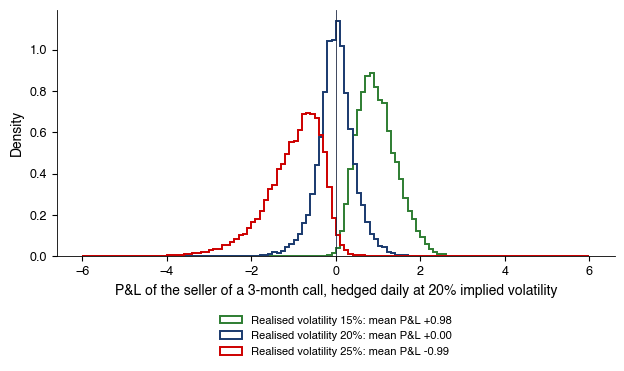

{'premium': 4.485236409022086,
 'vega': 0.19723966545394447,
 '15': {'mean': 0.984224677565108, 'sd': 0.4574100742449213, 'win': 0.998},
 '20': {'mean': 0.0006755838246728594,
  'sd': 0.43227864730422055,
  'win': 0.50665},
 '25': {'mean': -0.9933603811117013, 'sd': 0.6821649100460009, 'win': 0.02195}}

In [9]:
def fig_vol_mismatch():
    """Delta-hedged option seller at implied sigma 20% when realised volatility is 15%, 20% or 25%."""
    h = HEDGE
    prem = float(bs_price(h['S0'], h['K'], h['T'], h['r'], 0.20))
    vega = float(bs_greeks(h['S0'], h['K'], h['T'], h['r'], 0.20)['vega'])
    res = {}
    fig, ax = plt.subplots(figsize=(7.2, 3.2))
    bins = np.linspace(-6, 6, 121)
    for sr, c in [(0.15, Forest), (0.20, MainBlue), (0.25, IDAred)]:
        paths = gbm_paths(h['S0'], h['mu'], sr, h['T'], 63, h['npath'], seed=11)
        e = delta_hedge(paths, h['K'], h['T'], h['r'], 0.20, 63)
        res[f'{int(sr * 100)}'] = dict(mean=float(e.mean()), sd=float(e.std()), win=float((e > 0).mean()))
        ax.hist(e, bins=bins, histtype='step', lw=1.4, density=True, color=c,
                label=f'Realised volatility {int(sr * 100)}%: mean P&L {e.mean():+.2f}')
    ax.axvline(0, color=Gray, lw=0.6)
    ax.set_xlabel('P&L of the seller of a 3-month call, hedged daily at 20% implied volatility')
    ax.set_ylabel('Density')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch12_vol_mismatch')
    return dict(premium=prem, vega=vega, **res)


fig_vol_mismatch()

## 5. Selling S&P 500 volatility, 1990–2026

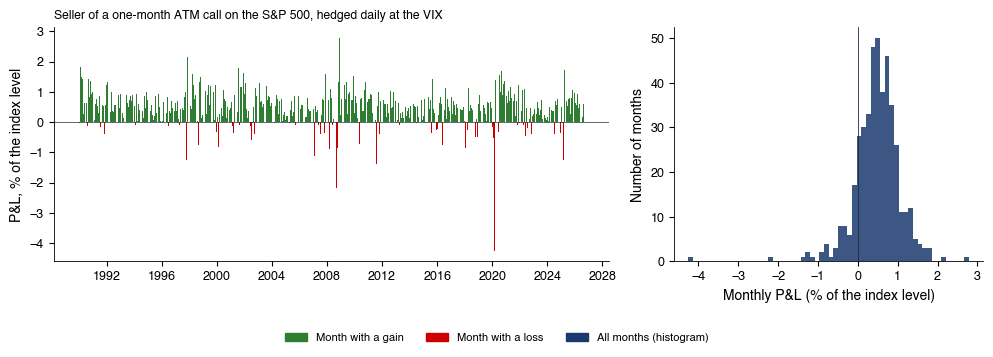

{'n': 440,
 'mean': 0.482837067402669,
 'se': 0.03011522399247448,
 't': 16.032989411711682,
 'sd': 0.5810856327636014,
 'win': 0.8590909090909091,
 'worst': -4.25243447094453,
 'worst_date': '2020-03',
 'best': 2.788771405953015,
 'prem': 2.221627979704301,
 'skew': -1.4617901563203735,
 'vix': 19.294727272727272,
 'rv': 15.318985890405559,
 'start': '1990-01',
 'share_vix_gt_rv': 0.8409090909090909}

In [10]:
def delta_hedged_history():
    """S&P 500: each month sell a 21-day ATM call priced at the VIX and delta-hedge it daily (1990-2026)."""
    px = pd.concat([load_close('sp500'), load_close('vix')], axis=1, join='inner').dropna()
    S, V = px['sp500'].values, px['vix'].values / 100
    dates = px.index
    H, T = 21, 21 / 252
    rows = []
    for i0 in range(0, len(px) - H, H):
        s0, sig = S[i0], V[i0]
        K = s0
        prem = float(bs_price(s0, K, T, 0.0, sig))
        delta = float(bs_greeks(s0, K, T, 0.0, sig)['delta'])
        cash = prem - delta * s0
        for i in range(1, H + 1):
            if i < H:
                d_new = float(bs_greeks(S[i0 + i], K, T * (H - i) / H, 0.0, sig)['delta'])
                cash -= (d_new - delta) * S[i0 + i]
                delta = d_new
        pnl = cash + delta * S[i0 + H] - max(S[i0 + H] - K, 0)
        rv = np.sqrt(252 / H * np.sum(np.diff(np.log(S[i0:i0 + H + 1])) ** 2))
        rows.append(dict(date=dates[i0], pnl=100 * pnl / s0, prem=100 * prem / s0, vix=sig * 100, rv=rv * 100))
    return pd.DataFrame(rows).set_index('date')


def fig_delta_hedged(d):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), gridspec_kw={'width_ratios': [1.8, 1]})
    ax = axes[0]
    ax.bar(d.index, d['pnl'], width=25, color=np.where(d['pnl'] >= 0, Forest, IDAred))
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_ylabel('P&L, % of the index level')
    ax.set_title('Seller of a one-month ATM call on the S&P 500, hedged daily at the VIX', fontsize=8.8, loc='left')
    ax = axes[1]
    ax.hist(d['pnl'], bins=60, color=MainBlue, alpha=0.85)
    ax.axvline(0, color=Gray, lw=0.6)
    ax.set_xlabel('Monthly P&L (% of the index level)'); ax.set_ylabel('Number of months')
    fig_legend_bottom(fig, [Patch(color=Forest, label='Month with a gain'), Patch(color=IDAred, label='Month with a loss'),
                            Patch(color=MainBlue, label='All months (histogram)')], ncol=3, y=-0.02)
    plt.tight_layout()
    save_fig('ch12_delta_hedged_sp500')
    m, se = nw_mean(d['pnl'], 3)
    w = d['pnl'].idxmin()
    return dict(n=int(len(d)), mean=m, se=se, t=m / se, sd=float(d['pnl'].std()), win=float((d['pnl'] > 0).mean()),
                worst=float(d['pnl'].min()), worst_date=w.strftime('%Y-%m'), best=float(d['pnl'].max()),
                prem=float(d['prem'].mean()), skew=float(stats.skew(d['pnl'])),
                vix=float(d['vix'].mean()), rv=float(d['rv'].mean()), start=d.index[0].strftime('%Y-%m'),
                share_vix_gt_rv=float((d['vix'] > d['rv']).mean()))


dh = delta_hedged_history()
fig_delta_hedged(dh)

## 6. Why smiles exist

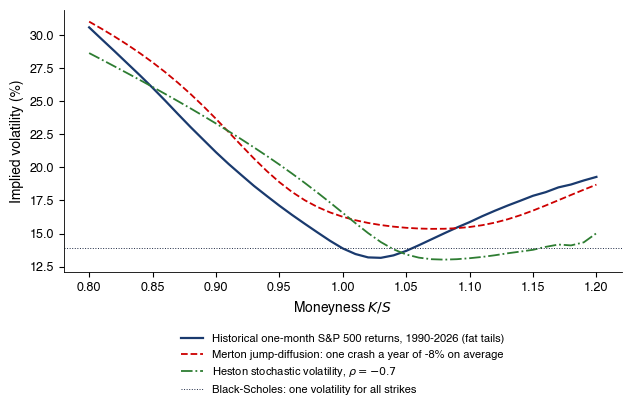

{'emp': {'k90': 21.138834249774597,
  'k100': 13.873356504401066,
  'k110': 15.860467781803585,
  'k80': 30.564791450973612,
  'k120': 19.274922188238595},
 'mer': {'k90': 23.65810992366324,
  'k100': 16.262394952384465,
  'k110': 15.491328677959595,
  'k80': 30.998469038298943,
  'k120': 18.689554529531893},
 'hes': {'k90': 23.307193297603064,
  'k100': 16.56125249844555,
  'k110': 13.135080118976406,
  'k80': 28.622990209590604,
  'k120': 15.021109843314301},
 'skew_R': -1.2747449424717021,
 'kurt_R': 6.846391878841832,
 'nR': 9225}

In [11]:
def smile_from_prices(S, Ks, T, price_fn):
    """Implied volatilities from prices: OTM puts below S, OTM calls above S."""
    out = []
    for K in Ks:
        kind = 'put' if K < S else 'call'
        out.append(implied_vol(price_fn(K, kind), S, K, T, 0.0, kind))
    return np.array(out)


def fig_smile_models():
    """One-month volatility smiles: empirical S&P 500 returns, Merton jumps, Heston stochastic volatility."""
    S, T = 100.0, 21 / 252
    Ks = np.linspace(80, 120, 41)
    lr = np.log(load_close('sp500'))
    R = (lr.shift(-21) - lr).dropna().values
    ST = S * np.exp(R) / np.mean(np.exp(R))           # risk-neutral mean (r = 0)
    emp = lambda K, kind: np.mean(np.maximum(ST - K, 0)) if kind == 'call' else np.mean(np.maximum(K - ST, 0))
    mer = lambda K, kind: float(merton_price(S, K, T, 0.0, 0.14, 1.0, -0.08, 0.08, kind))
    hes = lambda K, kind: heston_price(S, K, T, 0.0, 0.03, 3.0, 0.04, 0.8, -0.7, kind)
    iv = {'emp': smile_from_prices(S, Ks, T, emp), 'mer': smile_from_prices(S, Ks, T, mer),
          'hes': smile_from_prices(S, Ks, T, hes)}
    fig, ax = plt.subplots(figsize=(7.2, 3.4))
    ax.plot(Ks / S, 100 * iv['emp'], color=MainBlue, lw=1.6, label='Historical one-month S&P 500 returns, 1990-2026 (fat tails)')
    ax.plot(Ks / S, 100 * iv['mer'], color=IDAred, lw=1.3, ls='--', label='Merton jump-diffusion: one crash a year of -8% on average')
    ax.plot(Ks / S, 100 * iv['hes'], color=Forest, lw=1.3, ls='-.', label='Heston stochastic volatility, $\\rho = -0.7$')
    ax.axhline(100 * iv['emp'][20], color=Gray, lw=0.7, ls=':', label='Black-Scholes: one volatility for all strikes')
    ax.set_xlabel('Moneyness $K/S$'); ax.set_ylabel('Implied volatility (%)')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch12_smile_models')
    i90, i100, i110 = 10, 20, 30
    return {k: dict(k90=float(100 * v[i90]), k100=float(100 * v[i100]), k110=float(100 * v[i110]),
                    k80=float(100 * v[0]), k120=float(100 * v[-1])) for k, v in iv.items()} | dict(
        skew_R=float(stats.skew(R)), kurt_R=float(stats.kurtosis(R)), nR=int(len(R)))


fig_smile_models()

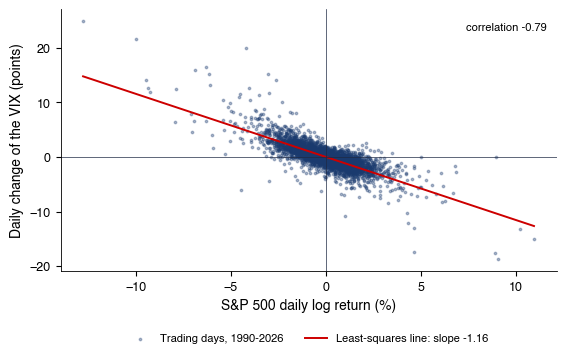

{'rho': -0.7867668794971895,
 'slope': -1.155155473930791,
 'n': 9244,
 'dv_down': 0.8806989247311828,
 'dv_up': -0.7599496069340859,
 'slope_dn': -1.3922644857502853,
 'slope_up': -1.0149984281725473}

In [12]:
def fig_leverage():
    """Leverage effect: daily S&P 500 return vs same-day VIX change (1990-2026)."""
    px = pd.concat([load_close('sp500'), load_close('vix')], axis=1, join='inner').dropna()
    r = 100 * np.log(px['sp500']).diff()
    dv = px['vix'].diff()
    d = pd.concat([r, dv], axis=1).dropna()
    d.columns = ['r', 'dv']
    b = np.polyfit(d['r'], d['dv'], 1)
    rho = float(d.corr().iloc[0, 1])
    up, dn = d[d['r'] > 0], d[d['r'] < 0]
    fig, ax = plt.subplots(figsize=(6.4, 3.4))
    ax.scatter(d['r'], d['dv'], s=3, color=MainBlue, alpha=0.35, label='Trading days, 1990-2026')
    xx = np.linspace(d['r'].min(), d['r'].max(), 10)
    ax.plot(xx, b[1] + b[0] * xx, color=IDAred, lw=1.4, label=f'Least-squares line: slope {b[0]:.2f}')
    ax.axhline(0, color=Gray, lw=0.5); ax.axvline(0, color=Gray, lw=0.5)
    ax.set_xlabel('S&P 500 daily log return (%)'); ax.set_ylabel('Daily change of the VIX (points)')
    ax.text(0.98, 0.95, f'correlation {rho:.2f}', transform=ax.transAxes, ha='right', va='top', fontsize=8, color='black')
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch12_leverage')
    return dict(rho=rho, slope=float(b[0]), n=int(len(d)), dv_down=float(dn['dv'].mean()), dv_up=float(up['dv'].mean()),
                slope_dn=float(np.polyfit(dn['r'], dn['dv'], 1)[0]), slope_up=float(np.polyfit(up['r'], up['dv'], 1)[0]))


fig_leverage()

## 7. Bitcoin options: smile, term structure, risk-neutral density

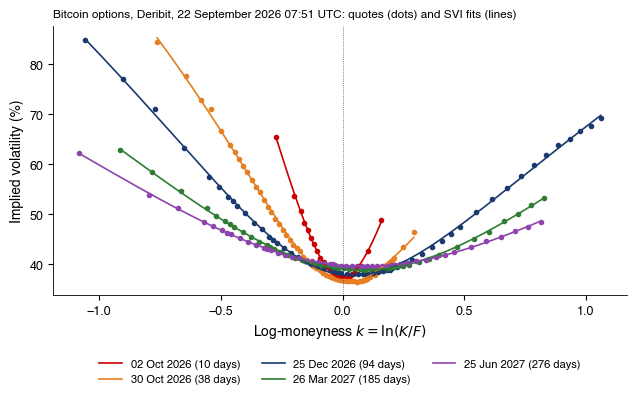

,days,F,n,atm,rr,rmse_iv,a,b,rho,m,s
expiry,,,,,,,,,,,
2026-09-24 08:00:00,2.006,85296.13,32.0,38.785,-2.368,0.686,-0.002,0.030,-0.001,0.004,0.101
2026-09-25 08:00:00,3.006,85320.63,25.0,39.054,-5.211,0.755,-0.012,0.062,-0.001,0.008,0.215
2026-10-02 08:00:00,10.006,85406.08,24.0,37.315,-0.263,0.300,-0.036,0.095,-0.125,-0.056,0.425
2026-10-09 08:00:00,17.006,85482.70,26.0,37.008,-2.576,0.479,-0.001,0.052,-0.480,-0.097,0.165
2026-10-30 08:00:00,38.006,85741.86,56.0,36.372,-2.108,0.423,-0.020,0.102,-0.262,-0.079,0.348
2026-11-27 08:00:00,66.006,86077.57,48.0,37.907,-2.374,0.131,-0.201,0.248,-0.296,-0.249,0.955
2026-12-25 08:00:00,94.006,86462.55,58.0,37.931,-1.828,0.355,-0.115,0.216,-0.241,-0.138,0.722
2027-03-26 08:00:00,185.006,87478.89,52.0,39.093,-1.682,0.135,-0.320,0.332,-0.081,-0.015,1.200
2027-06-25 08:00:00,276.006,88542.64,54.0,39.811,-1.212,0.069,-0.292,0.340,-0.156,-0.103,1.226


In [13]:
def btc_surface():
    """SVI fit for every expiry of the BTC chain (quoted OTM options, at least 2 days to expiry)."""
    c = deribit_chain()
    t0 = c['snapshot_utc'].iloc[0]
    c['T'] = (c['expiry'] - t0).dt.total_seconds() / (365 * 86400)
    c = c[(c['T'] >= 2 / 365) & (c['mark_iv'] > 0) & (c['bid'] > 0)]
    c = c[((c['type'] == 'put') & (c['strike'] < c['forward'])) | ((c['type'] == 'call') & (c['strike'] >= c['forward']))].copy()
    c['k'] = np.log(c['strike'] / c['forward'])
    c['w'] = (c['mark_iv'] / 100) ** 2 * c['T']
    c = c[c['k'].abs() < 1.2]
    fits = {}
    for e, g in c.groupby('expiry'):
        if len(g) < 7:
            continue
        f = svi_fit(g['k'].values, g['w'].values)
        T = g['T'].iloc[0]
        iv = lambda k: 100 * np.sqrt(svi_w(k, f['a'], f['b'], f['rho'], f['m'], f['s']) / T)
        fits[e] = dict(T=T, days=T * 365, F=float(g['forward'].iloc[0]), n=int(len(g)), atm=float(iv(0.0)),
                       rr=float(iv(0.15) - iv(-0.15)), wing_dn=float(iv(-0.3)), wing_up=float(iv(0.3)),
                       rmse_iv=float(np.sqrt(np.mean((iv(g['k'].values) - g['mark_iv'].values) ** 2))), **f)
    tab = pd.DataFrame(fits).T
    tab.index.name = 'expiry'
    tab.to_csv(os.path.join(HERE, 'ch12_btc_svi.csv'))
    return c, tab, t0


def pick(tab, days):
    """Expiry closest to a given number of days."""
    return (tab['days'] - days).abs().astype(float).idxmin()


def fig_btc_smile(c, tab, t0):
    fig, ax = plt.subplots(figsize=(7.4, 3.5))
    cols = [IDAred, Orange, MainBlue, Forest, Purple]
    chosen = []
    for dd in [7, 30, 90, 180, 280]:
        e = pick(tab, dd)
        if e not in chosen:
            chosen.append(e)
    for e, col in zip(chosen, cols):
        g = c[c['expiry'] == e]; f = tab.loc[e]
        kk = np.linspace(g['k'].min(), g['k'].max(), 200)
        ax.scatter(g['k'], g['mark_iv'], s=9, color=col)
        ax.plot(kk, 100 * np.sqrt(svi_w(kk, f['a'], f['b'], f['rho'], f['m'], f['s']) / f['T']), color=col, lw=1.2,
                label=f"{pd.Timestamp(e).strftime('%d %b %Y')} ({f['days']:.0f} days)")
    ax.axvline(0, color=Gray, lw=0.5, ls=':')
    ax.set_xlabel('Log-moneyness $k = \\ln(K/F)$'); ax.set_ylabel('Implied volatility (%)')
    ax.set_title(f"Bitcoin options, Deribit, {pd.Timestamp(t0).strftime('%d %B %Y %H:%M')} UTC: quotes (dots) and SVI fits (lines)",
                 fontsize=8.5, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch12_btc_smile')
    return [str(pd.Timestamp(e).date()) for e in chosen]


c, tab, t0 = btc_surface()
fig_btc_smile(c, tab, t0)
tab[['days', 'F', 'n', 'atm', 'rr', 'rmse_iv', 'a', 'b', 'rho', 'm', 's']].astype(float).round(3)

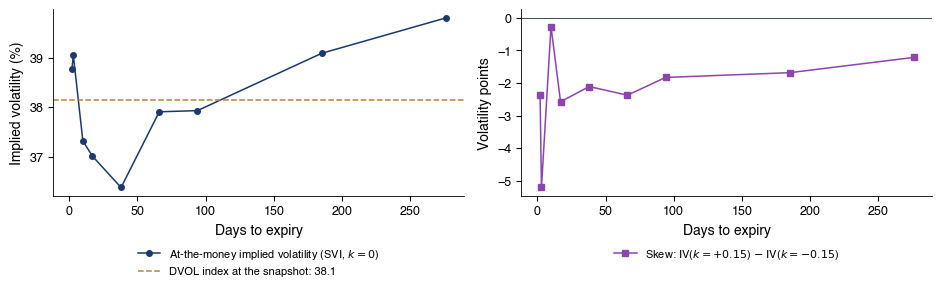

In [14]:
def dvol_now():
    """DVOL at the snapshot time: close of the last complete minute before the snapshot."""
    t0 = pd.Timestamp(deribit_chain()['snapshot_utc'].iloc[0]).tz_localize('UTC')
    t1 = int(t0.timestamp() * 1000)
    r = _get('get_volatility_index_data', currency='BTC', start_timestamp=t1 - 3_600_000, end_timestamp=t1, resolution='60')
    d = pd.DataFrame(r['data'], columns=['t', 'open', 'high', 'low', 'close'])
    d = d[d['t'] + 60_000 <= t1]
    last = d.iloc[-1]
    return float(last['close']), str(pd.to_datetime(last['t'] + 60_000, unit='ms'))


def fig_btc_term(tab, dvol_now):
    fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.1))
    ax = axes[0]
    ax.plot(tab['days'].astype(float), tab['atm'].astype(float), 'o-', color=MainBlue, ms=4, label='At-the-money implied volatility (SVI, $k = 0$)')
    ax.axhline(dvol_now, color=Amber, lw=1.1, ls='--', label=f'DVOL index at the snapshot: {dvol_now:.1f}')
    ax.set_xlabel('Days to expiry'); ax.set_ylabel('Implied volatility (%)')
    legend_outside_bottom(ax, ncol=1, y=-0.22)
    ax = axes[1]
    ax.plot(tab['days'].astype(float), tab['rr'].astype(float), 's-', color=Purple, ms=4,
            label='Skew: IV($k = +0.15$) $-$ IV($k = -0.15$)')
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xlabel('Days to expiry'); ax.set_ylabel('Volatility points')
    legend_outside_bottom(ax, ncol=1, y=-0.22)
    plt.tight_layout()
    save_fig('ch12_btc_term')


dv, dv_date = dvol_now()
fig_btc_term(tab, dv)

- No-arbitrage checks of every SVI slice: Lee's wing bound, the butterfly function $g(k)$, the calendar condition.

In [15]:
def svi_gk(k, a, b, rho, m, s):
    """Gatheral-Jacquier (2014) g(k): no butterfly arbitrage if g(k) >= 0 and w > 0."""
    W = svi_w(k, a, b, rho, m, s)
    W1 = b * (rho + (k - m) / np.sqrt((k - m) ** 2 + s ** 2))
    W2 = b * s ** 2 / ((k - m) ** 2 + s ** 2) ** 1.5
    return (1 - k * W1 / (2 * W)) ** 2 - W1 ** 2 / 4 * (1 / W + 0.25) + W2 / 2


def svi_no_arbitrage(tab):
    """No-arbitrage checks for every SVI slice: wing slopes (Lee, 2004), g(k) >= 0 and w(k) > 0
    (Gatheral-Jacquier, 2014), and calendar arbitrage dw/dtau >= 0 between consecutive expiries."""
    kg = np.linspace(-1.5, 1.5, 3001)
    rows = {}
    for e, f in tab.iterrows():
        p = [float(f[x]) for x in ['a', 'b', 'rho', 'm', 's']]
        rows[str(pd.Timestamp(e).date())] = dict(days=float(f['days']), slope_left=p[1] * (1 - p[2]),
                                                 slope_right=p[1] * (1 + p[2]), wmin=float(svi_w(kg, *p).min()),
                                                 gmin=float(svi_gk(kg, *p).min()))
    ex = list(tab.index)
    kc = np.linspace(-0.5, 0.5, 201)
    cal = []
    for e1, e2 in zip(ex[:-1], ex[1:]):
        p1 = [float(tab.loc[e1, x]) for x in ['a', 'b', 'rho', 'm', 's']]
        p2 = [float(tab.loc[e2, x]) for x in ['a', 'b', 'rho', 'm', 's']]
        dw = svi_w(kc, *p2) - svi_w(kc, *p1)
        cal.append(dict(e1=str(pd.Timestamp(e1).date()), e2=str(pd.Timestamp(e2).date()), min_dw=float(dw.min()),
                        share_viol=float((dw < 0).mean())))
    lee = max(max(r['slope_left'], r['slope_right']) for r in rows.values())
    return dict(per_expiry=rows, calendar=cal, max_slope=float(lee), n_exp=len(rows),
                n_g_neg=int(sum(r['gmin'] < 0 for r in rows.values())),
                n_w_neg=int(sum(r['wmin'] <= 0 for r in rows.values())),
                n_cal_viol=int(sum(c['min_dw'] < 0 for c in cal)), n_pairs=len(cal))


svi_no_arbitrage(tab)

{'per_expiry': {'2026-09-24': {'days': 2.00625,
   'slope_left': 0.030302188492701304,
   'slope_right': 0.03024456902757529,
   'wmin': 0.000824540575448712,
   'gmin': 0.12923851188607427},
  '2026-09-25': {'days': 3.0062499999999996,
   'slope_left': 0.061728630908054784,
   'slope_right': 0.061578049463460814,
   'wmin': 0.0012457007517437807,
   'gmin': 0.04769600772494852},
  '2026-10-02': {'days': 10.00625,
   'slope_left': 0.10699857724376312,
   'slope_right': 0.08326661342595314,
   'wmin': 0.0038167182019669676,
   'gmin': 0.04696753825080026},
  '2026-10-09': {'days': 17.006249999999998,
   'slope_left': 0.07650651113823388,
   'slope_right': 0.026889654169928296,
   'wmin': 0.006376015922085319,
   'gmin': 0.14160059701917496},
  '2026-10-30': {'days': 38.00625,
   'slope_left': 0.12819031603688652,
   'slope_right': 0.07504257153016743,
   'wmin': 0.013742362665784179,
   'gmin': 0.13593858844979528},
  '2026-11-27': {'days': 66.00625,
   'slope_left': 0.3214563805379878,

- Risk-neutral density with a 95% pairs-bootstrap band and the range of quoted strikes.

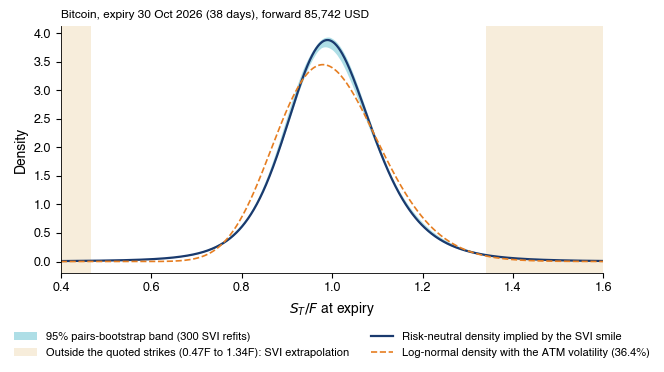

{'expiry': '2026-10-30',
 'days': 38.00625,
 'F': 85741.86,
 'atm': 36.37165153045735,
 'area': 0.999671921041769,
 'p80': 0.04281132662822667,
 'p120': 0.05328238761837101,
 'ln80': 0.03269582136723214,
 'ln120': 0.053467780979009505,
 'p70': 0.01206988333734691,
 'ln70': 0.0014398245934027362,
 'ext70': 0.001261706349662962,
 'ext70_share': 0.10453343370428124,
 'B': 300,
 'p70_lo': 0.010761157390222462,
 'p70_hi': 0.01244361642680597,
 'p80_lo': 0.04043215502353154,
 'p80_hi': 0.04455003874821819,
 'kf_min': 0.4665165882802169,
 'kf_max': 1.3412351913056237,
 'n_quotes': 56,
 'width_centre': 0.05075802774095489,
 'width_070': 0.16995038907797286}

In [16]:
def rnd_from_svi(p, F, T, K):
    """Risk-neutral density (Breeden-Litzenberger) from SVI parameters on the strike grid K."""
    k = np.log(K / F)
    sig = np.sqrt(np.clip(svi_w(k, *p), 1e-10, None) / T)
    C = bs_price(F, K, T, 0.0, sig, 'call')
    return np.clip(np.gradient(np.gradient(C, K), K), 0, None)


def btc_rnd(tab, c=None, days=30, B=300):
    """Risk-neutral density (Breeden-Litzenberger) from SVI for the expiry closest to 30 days;
    pairs-bootstrap band (SVI re-fitted on resampled quotes) and the range of observed quotes."""
    e = pick(tab, days); f = tab.loc[e]
    F, T = f['F'], f['T']
    p0 = [float(f[x]) for x in ['a', 'b', 'rho', 'm', 's']]
    K = F * np.exp(np.linspace(-1.2, 1.0, 2201))
    q = rnd_from_svi(p0, F, T, K)
    atm = np.sqrt(svi_w(0.0, *p0) / T)
    ln = stats.lognorm.pdf(K, s=atm * np.sqrt(T), scale=F * np.exp(-0.5 * atm ** 2 * T))
    area = integrate.trapezoid(q, K)
    below_q = lambda qq, x: float(integrate.trapezoid(qq[K <= x * F], K[K <= x * F]) / integrate.trapezoid(qq, K))
    below = lambda x: below_q(q, x)
    lnb = lambda x: float(stats.lognorm.cdf(x * F, s=atm * np.sqrt(T), scale=F * np.exp(-0.5 * atm ** 2 * T)))
    out = dict(expiry=str(pd.Timestamp(e).date()), days=float(f['days']), F=float(F), atm=float(100 * atm), area=float(area),
               p80=below(0.8), p120=1 - below(1.2), ln80=lnb(0.8), ln120=1 - lnb(1.2), p70=below(0.7), ln70=lnb(0.7))
    band = None
    if c is not None:
        g = c[c['expiry'] == e]
        kq, wq = g['k'].values, g['w'].values
        rng = np.random.default_rng(SEED)
        Q, P70, P80 = [], [], []
        while len(Q) < B:
            i = rng.integers(0, len(kq), len(kq))
            if len(np.unique(kq[i])) < 6:
                continue
            pb = svi_fit(kq[i], wq[i])
            qb = rnd_from_svi([pb[x] for x in ['a', 'b', 'rho', 'm', 's']], F, T, K)
            Q.append(qb); P70.append(below_q(qb, 0.7)); P80.append(below_q(qb, 0.8))
        Q = np.array(Q)
        band = (np.quantile(Q, 0.025, axis=0), np.quantile(Q, 0.975, axis=0))
        kmin, kmax = float(np.exp(kq.min())), float(np.exp(kq.max()))
        out.update(ext70=below(kmin), ext70_share=below(kmin) / out['p70'])   # mass below the last quote (SVI extrapolation)
        out.update(B=int(B), p70_lo=float(np.quantile(P70, 0.025)), p70_hi=float(np.quantile(P70, 0.975)),
                   p80_lo=float(np.quantile(P80, 0.025)), p80_hi=float(np.quantile(P80, 0.975)),
                   kf_min=kmin, kf_max=kmax, n_quotes=int(len(kq)),
                   width_centre=float((band[1] - band[0])[np.argmin(np.abs(K / F - 1))] / q[np.argmin(np.abs(K / F - 1))]),
                   width_070=float((band[1] - band[0])[np.argmin(np.abs(K / F - 0.7))] / max(q[np.argmin(np.abs(K / F - 0.7))], 1e-30)))
    fig, ax = plt.subplots(figsize=(7.0, 3.2))
    if band is not None:
        ax.fill_between(K / F, band[0] * F, band[1] * F, color=Teal, alpha=0.35, lw=0,
                        label=f'95% pairs-bootstrap band ({B} SVI refits)')
        ax.axvspan(0.3, out['kf_min'], color='#F5E6CC', alpha=0.7, lw=0,
                   label=f"Outside the quoted strikes ({out['kf_min']:.2f}F to {out['kf_max']:.2f}F): SVI extrapolation")
        ax.axvspan(out['kf_max'], 1.6, color='#F5E6CC', alpha=0.7, lw=0)
    ax.plot(K / F, q * F, color=MainBlue, lw=1.6, label='Risk-neutral density implied by the SVI smile')
    ax.plot(K / F, ln * F, color=Orange, lw=1.2, ls='--', label=f'Log-normal density with the ATM volatility ({100 * atm:.1f}%)')
    ax.set_xlim(0.4 if band is not None else 0.5, 1.6)
    ax.set_xlabel('$S_T/F$ at expiry'); ax.set_ylabel('Density')
    ax.set_title(f"Bitcoin, expiry {pd.Timestamp(e).strftime('%d %b %Y')} ({f['days']:.0f} days), forward {F:,.0f} USD",
                 fontsize=8.5, loc='left')
    legend_outside_bottom(ax, ncol=2 if band is not None else 1, y=-0.2)
    save_fig('ch12_btc_rnd')
    return out


btc_rnd(tab, c)

## 8. A VIX for Bitcoin (Cboe formula)

In [17]:
def cboe_strip(g, F, S):
    """Option strip of the Cboe formula for one expiry (Cboe, section 3(a)(iii)): K0 = first strike
    at or just below F; puts below K0 and calls above K0, excluding zero bids, stopping after two consecutive
    zero-bid strikes; at K0 the average of put and call. Q = mid price in USD
    (premium in BTC times the index S, Deribit convention)."""
    g = g.assign(mid=0.5 * (g['bid'] + g['ask']) * S, bid0=g['bid'].fillna(0.0))
    Ks = np.sort(g['strike'].unique())
    K0 = Ks[Ks <= F].max()
    side = {t: g[g['type'] == t].set_index('strike').sort_index() for t in ('put', 'call')}
    rows = []
    for t, seq in (('put', Ks[Ks < K0][::-1]), ('call', Ks[Ks > K0])):
        zeros = 0
        for K in seq:
            if K not in side[t].index or side[t].loc[K, 'bid0'] <= 0:
                zeros += 1
                if zeros == 2:
                    break
                continue
            zeros = 0
            rows.append((K, float(side[t].loc[K, 'mid'])))
    rows.append((K0, 0.5 * float(side['put'].loc[K0, 'mid'] + side['call'].loc[K0, 'mid'])))
    rows.sort()
    return np.array([r[0] for r in rows]), np.array([r[1] for r in rows]), float(K0)


def btc_vix(c_all=None):
    """30-day VIX-type index from the BTC chain (Cboe formula): mid prices in USD (premium in BTC x index S),
    rate R = ln(F/S)/T implied by the Deribit forward, so e^{RT} Q = premium in BTC x F."""
    c = deribit_chain() if c_all is None else c_all
    t0 = c['snapshot_utc'].iloc[0]
    c = c.copy()
    c['T'] = (c['expiry'] - t0).dt.total_seconds() / (365 * 86400)
    exps = sorted(c['expiry'].unique())
    Td = {e: c.loc[c['expiry'] == e, 'T'].iloc[0] * 365 for e in exps}
    near = max(e for e in exps if Td[e] < 30)
    nxt = min(e for e in exps if Td[e] >= 30)
    res = {}
    for tag, e in [('near', near), ('next', nxt)]:
        g = c[c['expiry'] == e]
        F = float(g['forward'].iloc[0]); S = float(g['index'].iloc[0]); T = float(g['T'].iloc[0])
        K, Q, K0 = cboe_strip(g, F, S)
        R = np.log(F / S) / T
        v = variance_from_strip(K, Q, F, T, R)
        res[tag] = dict(expiry=str(pd.Timestamp(e).date()), days=float(T * 365), F=F, S=S, R=float(R), K0=K0,
                        n=int(len(K)), var=float(v), vol=float(100 * np.sqrt(v)),
                        kf_min=float(K.min() / F), kf_max=float(K.max() / F))
    T1, T2 = res['near']['days'], res['next']['days']
    w1 = (T2 - 30) / (T2 - T1)
    v30 = (T1 * res['near']['var'] * w1 + T2 * res['next']['var'] * (1 - w1)) / 30
    res['index'] = float(100 * np.sqrt(v30))
    return res


btc_vix()

{'near': {'expiry': '2026-10-09',
  'days': 17.006249999999998,
  'F': 85482.13,
  'S': 85265.19,
  'R': 0.0545381340006745,
  'K0': 85000.0,
  'n': 26,
  'var': 0.15600460776684663,
  'vol': 39.49741862031576,
  'kf_min': 0.7603928446799348,
  'kf_max': 1.1698351456614382},
 'next': {'expiry': '2026-10-30',
  'days': 38.00625,
  'F': 85741.86,
  'S': 85265.19,
  'R': 0.05353930987053303,
  'K0': 85000.0,
  'n': 56,
  'var': 0.16143662534609282,
  'vol': 40.17917686390462,
  'kf_min': 0.4665165882802169,
  'kf_max': 1.3412351913056237},
 'index': 40.03281800792906}

- Truncation and discretisation of the strip; jump bias of the log contract in a Merton model.

In [18]:
def strip_variance(K, Q, F, T):
    """Integral 2/T * int Q(K)/K^2 dK (trapezoid) on a dense grid of OTM forward prices (puts below F, calls above F)."""
    return 2 / T * integrate.trapezoid(Q / K ** 2, K)


def btc_vix_bias(tab, c_all=None):
    """VIX-type index for Bitcoin: effect of discretising and truncating the strike strip
    (Jiang-Tian, 2005), with SVI prices instead of quotes; plus the jump gap vs quadratic variation in a Merton model."""
    c = deribit_chain() if c_all is None else c_all
    t0 = c['snapshot_utc'].iloc[0]
    c = c.copy()
    c['T'] = (c['expiry'] - t0).dt.total_seconds() / (365 * 86400)
    base = btc_vix(c_all)
    res = {}
    for tag in ['near', 'next']:
        e = pd.Timestamp(base[tag]['expiry'] + ' 08:00:00')
        g = c[c['expiry'] == e]
        F = float(g['forward'].iloc[0]); S = float(g['index'].iloc[0]); T = float(g['T'].iloc[0])
        Kq, _, K0 = cboe_strip(g, F, S)                                      # same strikes as the index
        f = tab.loc[e]
        p = [float(f[x]) for x in ['a', 'b', 'rho', 'm', 's']]
        def svi_q(K, split=F):
            """Forward price (e^{RT} x USD price) of the OTM option from SVI: put below split, call above."""
            sig = np.sqrt(np.clip(svi_w(np.log(K / F), *p), 1e-10, None) / T)
            return np.where(K < split, bs_price(F, K, T, 0.0, sig, 'put'), bs_price(F, K, T, 0.0, sig, 'call'))
        Qq = np.where(Kq == K0, 0.5 * (svi_q(Kq, np.inf) + svi_q(Kq, -np.inf)), svi_q(Kq, K0))
        v_q = variance_from_strip(Kq, Qq, F, T)                              # SVI at the quoted strikes, Cboe rule
        Kd = np.linspace(Kq.min(), Kq.max(), 20001)
        v_d = strip_variance(Kd, svi_q(Kd), F, T)                            # dense grid, same range
        Kw = F * np.exp(np.linspace(-4, 4, 40001))
        v_w = strip_variance(Kw, svi_q(Kw), F, T)                            # dense grid, extended range
        res[tag] = dict(days=float(T * 365), quoted=base[tag]['var'], svi_quoted=float(v_q), svi_dense=float(v_d),
                        svi_wide=float(v_w), kf_min=float(Kq.min() / F), kf_max=float(Kq.max() / F))
    T1, T2 = res['near']['days'], res['next']['days']
    w1 = (T2 - 30) / (T2 - T1)
    idx = lambda key: float(100 * np.sqrt((T1 * res['near'][key] * w1 + T2 * res['next'][key] * (1 - w1)) / 30))
    out = dict(res, index_quoted=idx('quoted'), index_svi_quoted=idx('svi_quoted'), index_svi_dense=idx('svi_dense'),
               index_svi_wide=idx('svi_wide'))
    # Merton jumps (parameters of the smile chart): E^Q[-2 ln(S_T/F)] / T vs E^Q[QV] / T
    sigma, lam, mu_j, sig_j = 0.14, 1.0, -0.08, 0.08
    # under the pricing measure of merton_price: intensity lam, log jumps ~ N(mu_j, sig_j^2)
    lq, mq = lam, mu_j
    EJ2 = mq ** 2 + sig_j ** 2
    EeJ = np.exp(mq + 0.5 * sig_j ** 2)
    qv = sigma ** 2 + lq * EJ2
    strip = sigma ** 2 + 2 * lq * (EeJ - 1 - mq)
    out['merton'] = dict(qv=float(qv), strip=float(strip), vol_qv=float(100 * np.sqrt(qv)), vol_strip=float(100 * np.sqrt(strip)),
                         rel=float(strip / qv - 1))
    return out


btc_vix_bias(tab)

{'near': {'days': 17.006249999999998,
  'quoted': 0.15600460776684663,
  'svi_quoted': 0.156116640529135,
  'svi_dense': 0.15250532941951223,
  'svi_wide': 0.16003903739143915,
  'kf_min': 0.7603928446799348,
  'kf_max': 1.1698351456614382},
 'next': {'days': 38.00625,
  'quoted': 0.16143662534609282,
  'svi_quoted': 0.16100882137834518,
  'svi_dense': 0.15979553098853405,
  'svi_wide': 0.1635113099163187,
  'kf_min': 0.4665165882802169,
  'kf_max': 1.3412351913056237},
 'index_quoted': 40.03281800792906,
 'index_svi_quoted': 39.99393927864459,
 'index_svi_dense': 39.776873262208426,
 'index_svi_wide': 40.34363377045301,
 'merton': {'qv': 0.032400000000000005,
  'strip': 0.031750100192496716,
  'vol_qv': 18.000000000000004,
  'vol_strip': 17.818557795875826,
  'rel': -0.020058636034052113}}

## 9. The VIX: history, term structure, VVIX

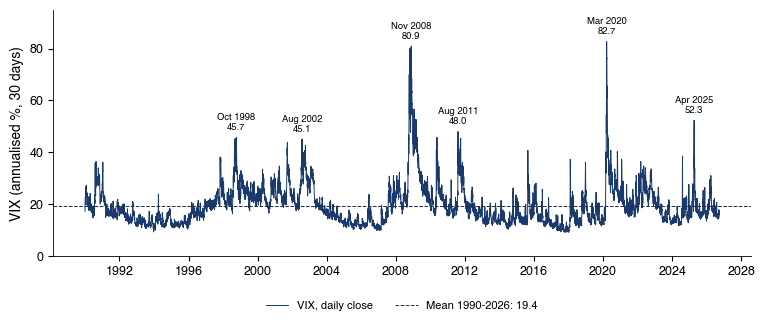

{'mean': 19.431839724256786,
 'median': 17.58,
 'min': 9.14,
 'min_date': '2017-11-03',
 'max': 82.69,
 'max_date': '2020-03-16',
 'share30': 0.07938388625592417,
 'share15': 0.32001292546316246,
 'last': 14.81,
 'n': 9284,
 'peaks': [('2020-03-16', 82.69),
  ('2008-11-20', 80.86),
  ('2025-04-08', 52.33),
  ('2011-08-08', 48.0),
  ('1998-10-08', 45.74),
  ('2002-08-05', 45.08)]}

In [19]:
def fig_vix_history():
    v = load_close('vix')
    peaks = []
    s = v.copy()
    for _ in range(6):
        d = s.idxmax()
        peaks.append((d, float(v[d])))
        s = s[(s.index < d - pd.Timedelta(days=500)) | (s.index > d + pd.Timedelta(days=500))]
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(v.index, v.values, color=MainBlue, lw=0.7, label='VIX, daily close')
    ax.axhline(v.mean(), color=Gray, lw=0.7, ls='--', label=f'Mean 1990-2026: {v.mean():.1f}')
    for d, x in peaks:
        ax.annotate(f"{d.strftime('%b %Y')}\n{x:.1f}", (d, x), xytext=(0, 4), textcoords='offset points', ha='center',
                    va='bottom', fontsize=6.8, color='black')
    ax.set_ylim(0, 95); ax.set_ylabel('VIX (annualised %, 30 days)')
    legend_outside_bottom(ax, ncol=2, y=-0.14)
    save_fig('ch12_vix_history')
    return dict(mean=float(v.mean()), median=float(v.median()), min=float(v.min()), min_date=str(v.idxmin().date()),
                max=float(v.max()), max_date=str(v.idxmax().date()), share30=float((v > 30).mean()),
                share15=float((v < 15).mean()), last=float(v.iloc[-1]), n=int(len(v)),
                peaks=[(str(d.date()), x) for d, x in peaks])


fig_vix_history()

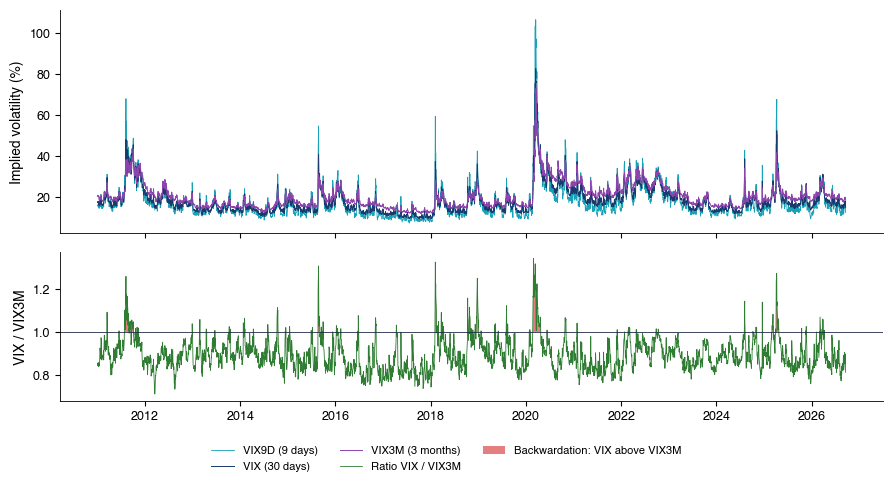

{'start': '2011-01-03',
 'n': 3951,
 'share_back': 0.0756770437863832,
 'mean_ratio': 0.8933691336576975,
 'share_9d_below': 0.7342444950645406,
 'fwd_back': 2.8764520394516295,
 'fwd_cont': 0.7960386869677074,
 'rv_back': 26.72797188286014,
 'rv_cont': 13.568826497928903,
 'last_ratio': 0.811951754385965,
 'last_vix9d': 12.27,
 'last_vix3m': 18.24}

In [20]:
def fig_vix_term():
    px = pd.concat([load_close('vix9d'), load_close('vix'), load_close('vix3m'), load_close('sp500')], axis=1, join='inner').dropna()
    ratio = px['vix'] / px['vix3m']
    fig, axes = plt.subplots(2, 1, figsize=(9, 4.4), sharex=True, gridspec_kw={'height_ratios': [1.5, 1]})
    ax = axes[0]
    ax.plot(px.index, px['vix9d'], color=Teal, lw=0.6, label='VIX9D (9 days)')
    ax.plot(px.index, px['vix'], color=MainBlue, lw=0.7, label='VIX (30 days)')
    ax.plot(px.index, px['vix3m'], color=Purple, lw=0.7, label='VIX3M (3 months)')
    ax.set_ylabel('Implied volatility (%)')
    ax = axes[1]
    ax.plot(ratio.index, ratio.values, color=Forest, lw=0.6, label='Ratio VIX / VIX3M')
    ax.fill_between(ratio.index, 1, ratio.values, where=ratio.values > 1, color=IDAred, alpha=0.5, lw=0,
                    label='Backwardation: VIX above VIX3M')
    ax.axhline(1, color=Gray, lw=0.6)
    ax.set_ylabel('VIX / VIX3M')
    h1, l1 = axes[0].get_legend_handles_labels(); h2, l2 = axes[1].get_legend_handles_labels()
    fig.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
    plt.tight_layout()
    save_fig('ch12_vix_term')
    lr = np.log(px['sp500'])
    fwd = 100 * (lr.shift(-21) - lr)
    rv = 100 * np.sqrt(252 / 21 * (lr.diff() ** 2).rolling(21).sum().shift(-21))
    back = ratio > 1
    ok = fwd.notna()
    return dict(start=str(px.index[0].date()), n=int(len(px)), share_back=float(back.mean()),
                mean_ratio=float(ratio.mean()), share_9d_below=float((px['vix9d'] < px['vix']).mean()),
                fwd_back=float(fwd[back & ok].mean()), fwd_cont=float(fwd[~back & ok].mean()),
                rv_back=float(rv[back & rv.notna()].mean()), rv_cont=float(rv[~back & rv.notna()].mean()),
                last_ratio=float(ratio.iloc[-1]), last_vix9d=float(px['vix9d'].iloc[-1]), last_vix3m=float(px['vix3m'].iloc[-1]))


fig_vix_term()

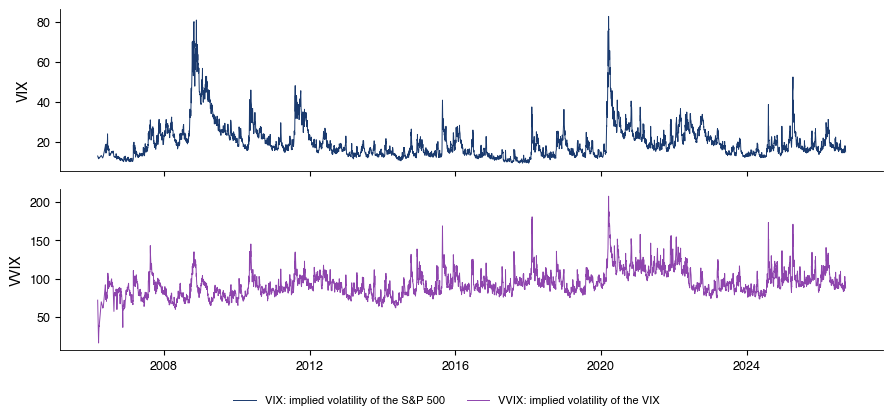

{'start': '2006-03-06',
 'mean': 93.45145290777363,
 'max': 207.59,
 'max_date': '2020-03-16',
 'corr_d': 0.7092744186711328,
 'corr_lvl': 0.4247890843888767,
 'ratio': 5.303576107584369}

In [21]:
def fig_vvix():
    px = pd.concat([load_close('vix'), load_close('vvix')], axis=1, join='inner').dropna()
    fig, axes = plt.subplots(2, 1, figsize=(9, 3.9), sharex=True)
    axes[0].plot(px.index, px['vix'], color=MainBlue, lw=0.7, label='VIX: implied volatility of the S&P 500')
    axes[1].plot(px.index, px['vvix'], color=Purple, lw=0.7, label='VVIX: implied volatility of the VIX')
    axes[0].set_ylabel('VIX'); axes[1].set_ylabel('VVIX')
    h1, l1 = axes[0].get_legend_handles_labels(); h2, l2 = axes[1].get_legend_handles_labels()
    fig.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False)
    plt.tight_layout()
    save_fig('ch12_vvix')
    d = px.diff().dropna()
    return dict(start=str(px.index[0].date()), mean=float(px['vvix'].mean()), max=float(px['vvix'].max()),
                max_date=str(px['vvix'].idxmax().date()), corr_d=float(d.corr().iloc[0, 1]),
                corr_lvl=float(px.corr().iloc[0, 1]), ratio=float((px['vvix'] / px['vix']).mean()))


fig_vvix()

## 10. The variance risk premium

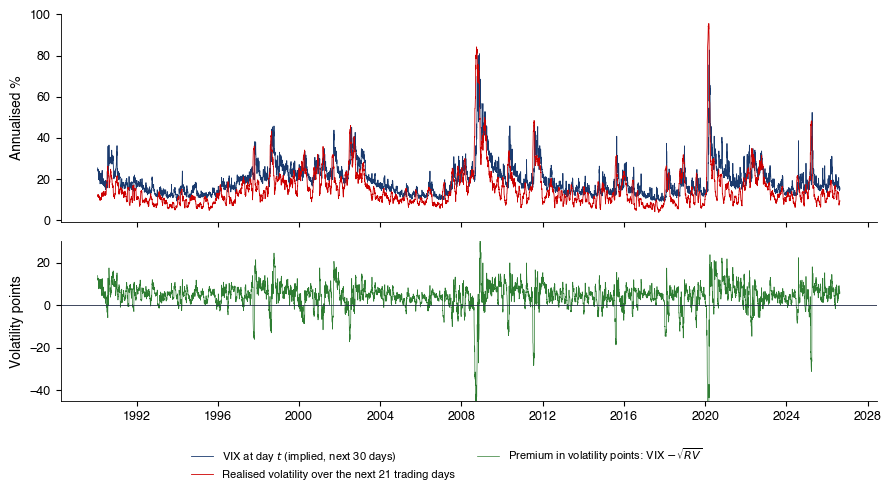

{'n': 9203, 'start': '1990-01-31', 'end': '2026-08-19', 'mean': 113.1422810966194, 'se': 20.621026303086406, 't': 5.486743454649737, 'mean_vol': 4.0914362055217435, 'se_vol': 0.2666941672924536, 'share_pos': 0.858307073780289, 'vix': 19.43508964468108, 'rv': 15.343653439159336, 'worst': -71.9626196775916, 'worst_date': '2020-02-20', 'median_vol': 4.7091147635686665}


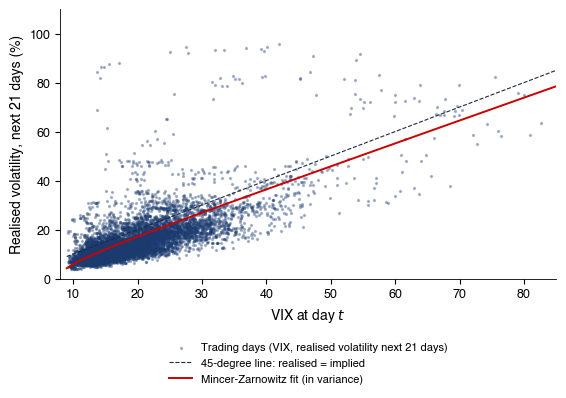

{'a': -51.86881826307021,
 'a_se': 34.4336652910969,
 'b': 0.8599763883377426,
 'b_se': 0.1046493476371911,
 'r2': 0.3740092493971351,
 't_b1': -1.338026608132383,
 'r2_past': 0.2877653006613611,
 'r2_both': 0.375810807801914,
 'b_both': 0.7677831124984075,
 'c_both': 0.07811058340617509,
 'b_both_se': 0.13678865191718081,
 'c_both_se': 0.13111827060198708}

In [22]:
def vrp_sp500():
    """Variance risk premium: VIX^2 minus realised variance over the next 21 trading days."""
    px = pd.concat([load_close('sp500'), load_close('vix')], axis=1, join='inner').dropna()
    r = np.log(px['sp500']).diff()
    rv = 252 / 21 * (r ** 2).rolling(21).sum().shift(-21) * 1e4       # annualised (%)^2
    d = pd.DataFrame({'vix': px['vix'], 'iv2': px['vix'] ** 2, 'rv': rv, 'rv_past': rv.shift(21)}).dropna()
    d['vrp'] = d['iv2'] - d['rv']
    d['vrp_vol'] = d['vix'] - np.sqrt(d['rv'])
    return d


def fig_vrp(d):
    fig, axes = plt.subplots(2, 1, figsize=(9, 4.4), sharex=True, gridspec_kw={'height_ratios': [1.3, 1]})
    ax = axes[0]
    ax.plot(d.index, d['vix'], color=MainBlue, lw=0.6, label='VIX at day $t$ (implied, next 30 days)')
    ax.plot(d.index, np.sqrt(d['rv']), color=IDAred, lw=0.6, label='Realised volatility over the next 21 trading days')
    ax.set_ylabel('Annualised %')
    ax = axes[1]
    ax.plot(d.index, d['vrp_vol'], color=Forest, lw=0.5, label='Premium in volatility points: VIX $-\\sqrt{RV}$')
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_ylabel('Volatility points'); ax.set_ylim(-45, 30)
    h1, l1 = axes[0].get_legend_handles_labels(); h2, l2 = axes[1].get_legend_handles_labels()
    fig.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False)
    plt.tight_layout()
    save_fig('ch12_vrp')
    m, se = nw_mean(d['vrp'], 21)
    mv, sev = nw_mean(d['vrp_vol'], 21)
    w = d['vrp_vol'].idxmin()
    return dict(n=int(len(d)), start=str(d.index[0].date()), end=str(d.index[-1].date()), mean=m, se=se, t=m / se,
                mean_vol=mv, se_vol=sev, share_pos=float((d['vrp'] > 0).mean()), vix=float(d['vix'].mean()),
                rv=float(np.sqrt(d['rv']).mean()), worst=float(d['vrp_vol'].min()), worst_date=str(w.date()),
                median_vol=float(d['vrp_vol'].median()))


def fig_mz(d):
    """Mincer-Zarnowitz regression: future realised variance on VIX^2 (Newey-West standard errors, 21 lags)."""
    X = sm.add_constant(d[['iv2']])
    m1 = sm.OLS(d['rv'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
    m2 = sm.OLS(d['rv'], sm.add_constant(d[['rv_past']])).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
    m3 = sm.OLS(d['rv'], sm.add_constant(d[['iv2', 'rv_past']])).fit(cov_type='HAC', cov_kwds={'maxlags': 21})
    fig, ax = plt.subplots(figsize=(6.4, 3.5))
    ax.scatter(d['vix'], np.sqrt(d['rv']), s=2, color=MainBlue, alpha=0.3, label='Trading days (VIX, realised volatility next 21 days)')
    xx = np.linspace(9, 85, 50)
    ax.plot(xx, xx, color=Gray, lw=0.8, ls='--', label='45-degree line: realised = implied')
    ax.plot(xx, np.sqrt(np.clip(m1.params['const'] + m1.params['iv2'] * xx ** 2, 0, None)), color=IDAred, lw=1.4,
            label='Mincer-Zarnowitz fit (in variance)')
    ax.set_xlabel('VIX at day $t$'); ax.set_ylabel('Realised volatility, next 21 days (%)')
    ax.set_xlim(8, 85); ax.set_ylim(0, 110)
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch12_vix_rv_mz')
    wald = m1.t_test('iv2 = 1')
    return dict(a=float(m1.params['const']), a_se=float(m1.bse['const']), b=float(m1.params['iv2']), b_se=float(m1.bse['iv2']),
                r2=float(m1.rsquared), t_b1=float(wald.tvalue), r2_past=float(m2.rsquared), r2_both=float(m3.rsquared),
                b_both=float(m3.params['iv2']), c_both=float(m3.params['rv_past']),
                b_both_se=float(m3.bse['iv2']), c_both_se=float(m3.bse['rv_past']))


vd = vrp_sp500()
print(fig_vrp(vd))
fig_mz(vd)

- The VIX as a forecast: joint Mincer–Zarnowitz test, logs, instrumental variables, encompassing HAR-RV, out-of-sample QLIKE and Diebold–Mariano.

In [23]:
def qlike(rv, f):
    return rv / f - np.log(rv / f) - 1


def hac_se(u, lags):
    """HAC (Newey-West, Bartlett) standard error of the mean of a series."""
    u = np.asarray(u, float)
    return nw_mean(u, lags)[1]


def iv_gmm(y, X, Z, lags):
    """Just-identified IV estimator, b = (Z'X)^{-1} Z'y, with HAC (Newey-West) variance of the moments Z u."""
    b = np.linalg.solve(Z.T @ X, Z.T @ y)
    u = y - X @ b
    g = Z * u[:, None]
    T = len(y)
    S = g.T @ g / T
    for L in range(1, lags + 1):
        G = g[L:].T @ g[:-L] / T
        S += (1 - L / (lags + 1)) * (G + G.T)
    A = np.linalg.inv(Z.T @ X / T)
    V = A @ S @ A.T / T
    return b, np.sqrt(np.diag(V))


def vix_forecast_inference():
    """VIX as a forecast of 21-day realised variance: joint Mincer-Zarnowitz test, log specification,
    errors in variables (IV with lagged VIX^2, Christensen-Prabhala), encompassing against HAR-RV (Corsi; Busch et al.)
    and out-of-sample comparison with the QLIKE loss and the Diebold-Mariano test (Patton, 2011)."""
    d = vrp_sp500().copy()
    out = {}
    L = 21
    m = sm.OLS(d['rv'], sm.add_constant(d[['iv2']])).fit(cov_type='HAC', cov_kwds={'maxlags': L})
    w = m.wald_test('const = 0, iv2 = 1', scalar=True)
    cv = m.cov_params()
    out['lev'] = dict(a=float(m.params['const']), b=float(m.params['iv2']), a_se=float(m.bse['const']), b_se=float(m.bse['iv2']),
                      corr_ab=float(cv.loc['const', 'iv2'] / np.sqrt(cv.loc['const', 'const'] * cv.loc['iv2', 'iv2'])),
                      wald=float(w.statistic), wald_p=float(w.pvalue), n=int(len(d)), r2=float(m.rsquared))
    px = pd.concat([load_close('sp500'), load_close('vix')], axis=1, join='inner').dropna()
    rd = (np.log(px['sp500']).diff() ** 2 * 252 * 1e4)
    d['har_d'] = rd.reindex(d.index)
    d['har_w'] = rd.rolling(5).mean().reindex(d.index)
    d['har_m'] = rd.rolling(22).mean().reindex(d.index)
    d['iv2_lag'] = d['iv2'].shift(21)
    d = d.dropna()
    ly, lx = np.log(d['rv']), np.log(d['iv2'])
    ml = sm.OLS(ly, sm.add_constant(lx.rename('liv2'))).fit(cov_type='HAC', cov_kwds={'maxlags': L})
    wl = ml.wald_test('liv2 = 1', scalar=True)
    out['log'] = dict(a=float(ml.params['const']), b=float(ml.params['liv2']), a_se=float(ml.bse['const']),
                      b_se=float(ml.bse['liv2']), r2=float(ml.rsquared), t_b1=float((ml.params['liv2'] - 1) / ml.bse['liv2']),
                      wald_b1=float(wl.statistic), wald_b1_p=float(wl.pvalue))
    X = np.column_stack([np.ones(len(d)), lx.values])
    Z = np.column_stack([np.ones(len(d)), np.log(d['iv2_lag']).values])
    b, se = iv_gmm(ly.values, X, Z, L)
    fs = sm.OLS(lx, sm.add_constant(np.log(d['iv2_lag']).rename('z'))).fit(cov_type='HAC', cov_kwds={'maxlags': L})
    out['iv'] = dict(a=float(b[0]), b=float(b[1]), a_se=float(se[0]), b_se=float(se[1]), t_b1=float((b[1] - 1) / se[1]),
                     first_stage_t=float(fs.tvalues['z']), first_stage_r2=float(fs.rsquared))
    # encompassing: log RV on log VIX^2 and the HAR components in logs
    for c_ in ['har_d', 'har_w', 'har_m']:
        d['l' + c_] = np.log(d[c_].clip(lower=1e-2))
    me = sm.OLS(ly, sm.add_constant(pd.concat([lx.rename('liv2'), d[['lhar_d', 'lhar_w', 'lhar_m']]], axis=1))).fit(
        cov_type='HAC', cov_kwds={'maxlags': L})
    mh = sm.OLS(ly, sm.add_constant(d[['lhar_d', 'lhar_w', 'lhar_m']])).fit(cov_type='HAC', cov_kwds={'maxlags': L})
    wh = me.wald_test('lhar_d = 0, lhar_w = 0, lhar_m = 0', scalar=True)
    out['enc'] = dict(b_iv=float(me.params['liv2']), b_iv_se=float(me.bse['liv2']), r2=float(me.rsquared),
                      r2_har=float(mh.rsquared), r2_iv=float(ml.rsquared), wald_har=float(wh.statistic),
                      wald_har_p=float(wh.pvalue), b_m=float(me.params['lhar_m']), b_m_se=float(me.bse['lhar_m']))
    # out of sample (from 2000): coefficients re-estimated every 21 days, using only targets already observed
    idx = d.index
    start = np.searchsorted(idx, pd.Timestamp('2000-01-03'))
    F_raw, F_mz, F_har, RV = [], [], [], []
    b_mz = b_har = None
    Xh_all = sm.add_constant(d[['lhar_d', 'lhar_w', 'lhar_m']]).values
    Xm_all = sm.add_constant(lx.rename('liv2')).values
    for i in range(start, len(d)):
        if (i - start) % 21 == 0:
            tr = slice(0, i - 21)                       # targets RV_{s, s+21} known at date i: s <= i - 21
            b_har = np.linalg.lstsq(Xh_all[tr], ly.values[tr], rcond=None)[0]
            b_mz = np.linalg.lstsq(Xm_all[tr], ly.values[tr], rcond=None)[0]
            s2h = np.var(ly.values[tr] - Xh_all[tr] @ b_har)
            s2m = np.var(ly.values[tr] - Xm_all[tr] @ b_mz)
        F_raw.append(d['iv2'].values[i])
        F_mz.append(np.exp(Xm_all[i] @ b_mz + 0.5 * s2m))   # level forecast from the log regression
        F_har.append(np.exp(Xh_all[i] @ b_har + 0.5 * s2h))
        RV.append(d['rv'].values[i])
    F_raw, F_mz, F_har, RV = map(np.array, (F_raw, F_mz, F_har, RV))
    oos = dict(start=str(idx[start].date()), n=int(len(RV)))
    for name, Fc in [('raw', F_raw), ('mz', F_mz)]:
        for lname, lf in [('qlike', qlike), ('mse', lambda y, f: (y - f) ** 2)]:
            dl = lf(RV, Fc) - lf(RV, F_har)          # < 0: VIX better than HAR
            se = hac_se(dl, L)
            oos[f'{name}_{lname}'] = dict(loss=float(lf(RV, Fc).mean()), loss_har=float(lf(RV, F_har).mean()),
                                          ratio=float(lf(RV, Fc).mean() / lf(RV, F_har).mean()), dm=float(dl.mean() / se),
                                          p=float(2 * (1 - stats.norm.cdf(abs(dl.mean() / se)))))
    out['oos'] = oos
    return out


vix_forecast_inference()

{'lev': {'a': -51.86881826307021,
  'b': 0.8599763883377426,
  'a_se': 34.4336652910969,
  'b_se': 0.1046493476371911,
  'corr_ab': -0.9029418425380635,
  'wald': 41.685667323522026,
  'wald_p': 8.873038245607175e-10,
  'n': 9203,
  'r2': 0.3740092493971351},
 'log': {'a': -0.9370056082651258,
  'b': 1.058204866287229,
  'a_se': 0.20568565473606026,
  'b_se': 0.0352214483122256,
  'r2': 0.569673865915731,
  't_b1': 1.6525404001352688,
  'wald_b1': 2.730889774079235,
  'wald_b1_p': 0.09842443641554358},
 'iv': {'a': -0.7432152874363198,
  'b': 1.0248374657193042,
  'a_se': 0.24658015044662304,
  'b_se': 0.04167132681165563,
  't_b1': 0.5960325149127984,
  'first_stage_t': 37.696861668732616,
  'first_stage_r2': 0.6366786472876086},
 'enc': {'b_iv': 0.8962677946796971,
  'b_iv_se': 0.0560562203759297,
  'r2': 0.5746457151036498,
  'r2_har': 0.47353510337546645,
  'r2_iv': 0.569673865915731,
  'wald_har': 14.227237430430815,
  'wald_har_p': 0.0026116075180589167,
  'b_m': 0.07085354607178

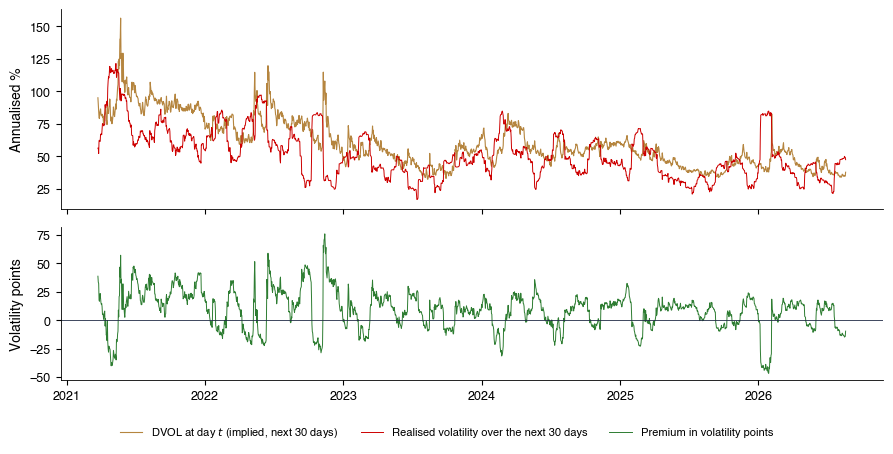

{'n': 1975,
 'start': '2021-03-24',
 'end': '2026-08-19',
 'mean': 953.1173805053692,
 'se': 219.2764313878636,
 't': 4.346647628624814,
 'mean_vol': 8.527219746026034,
 'se_vol': 1.601951396169549,
 't_vol': 5.32302026541854,
 'share_pos': 0.7129113924050633,
 'dvol': 60.25784303797469,
 'rv': 51.730623291948646,
 'worst': -46.853059256028544,
 'worst_date': '2026-01-28'}

In [24]:
def vrp_btc():
    """Bitcoin: DVOL minus realised volatility over the next 30 calendar days."""
    dv = dvol_history()
    p = load_close('btc')
    r = np.log(p).diff()
    rv = 365 / 30 * (r ** 2).rolling(30).sum().shift(-30) * 1e4
    d = pd.concat([dv, rv.rename('rv')], axis=1, join='inner').dropna()
    d['vrp'] = d['dvol'] ** 2 - d['rv']
    d['vrp_vol'] = d['dvol'] - np.sqrt(d['rv'])
    return d


def fig_vrp_btc(d):
    fig, axes = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True, gridspec_kw={'height_ratios': [1.3, 1]})
    axes[0].plot(d.index, d['dvol'], color=Amber, lw=0.8, label='DVOL at day $t$ (implied, next 30 days)')
    axes[0].plot(d.index, np.sqrt(d['rv']), color=IDAred, lw=0.7, label='Realised volatility over the next 30 days')
    axes[0].set_ylabel('Annualised %')
    axes[1].plot(d.index, d['vrp_vol'], color=Forest, lw=0.7, label='Premium in volatility points')
    axes[1].axhline(0, color=Gray, lw=0.6)
    axes[1].set_ylabel('Volatility points')
    h1, l1 = axes[0].get_legend_handles_labels(); h2, l2 = axes[1].get_legend_handles_labels()
    fig.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
    plt.tight_layout()
    save_fig('ch12_vrp_btc')
    m, se = nw_mean(d['vrp'], 30)
    mv, sev = nw_mean(d['vrp_vol'], 30)
    return dict(n=int(len(d)), start=str(d.index[0].date()), end=str(d.index[-1].date()), mean=m, se=se, t=m / se,
                mean_vol=mv, se_vol=sev, t_vol=mv / sev, share_pos=float((d['vrp'] > 0).mean()),
                dvol=float(d['dvol'].mean()), rv=float(np.sqrt(d['rv']).mean()),
                worst=float(d['vrp_vol'].min()), worst_date=str(d['vrp_vol'].idxmin().date()))


fig_vrp_btc(vrp_btc())

- Does the ex-ante variance risk premium predict S&P 500 excess returns? Newey–West, Hansen–Hodrick and Hodrick (1992) errors; bootstrap under the null.

In [25]:
def vrp_monthly():
    """Monthly data as in BTZ (2009): IV = month-end VIX^2/12, RV = sum of squared daily returns (%) in the month,
    VRP = IV - RV (ex ante), excess return = monthly S&P 500 log return minus TB3MS/12 (FRED)."""
    spx, vix = read_market('GSPC.INDX')['close'], read_market('VIX.INDX')['close']
    px = pd.concat([spx, vix], axis=1, keys=['spx', 'vix']).dropna()
    r = 100 * np.log(px['spx']).diff().dropna()
    rv = (r ** 2).resample('ME').sum()
    iv = (px['vix'] ** 2 / 12).resample('ME').last()
    rm = 100 * np.log(px['spx'].resample('ME').last()).diff()
    tb = pd.read_csv('https://fred.stlouisfed.org/graph/fredgraph.csv?id=TB3MS', index_col=0, parse_dates=True).iloc[:, 0]
    tb.index = tb.index + pd.offsets.MonthEnd(0)
    df = pd.DataFrame({'iv': iv, 'rv': rv, 'rm': rm, 'rf': tb / 12}).dropna()
    df = df[df.index >= '1990-01-31']
    df['vrp'] = df['iv'] - df['rv']
    df['ex'] = df['rm'] - df['rf']
    return df


def hodrick_t(y, X, e1, h):
    """Hodrick (1992) 1B standard errors for the overlapping-return regression (sum of past regressors)."""
    T = len(y)
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    Z = X.T @ X / T
    S = np.zeros((X.shape[1], X.shape[1]))
    for t in range(h - 1, T):
        w = e1[t] * X[t - h + 1:t + 1].sum(axis=0)
        S += np.outer(w, w)
    S /= T
    Zi = np.linalg.inv(Z)
    V = Zi @ S @ Zi / T
    return b, b / np.sqrt(np.diag(V))


def vrp_predict(B=2000):
    """Return predictability by the ex-ante VRP (BTZ, 2009): overlapping monthly regressions for h = 1, 3, 6, 12 months,
    with Newey-West (h lags), Hansen-Hodrick (h - 1 lags, uniform kernel) and Hodrick (1992) 1B standard errors;
    bootstrap p-value under H0 (VRP as AR(1), residuals resampled jointly; Stambaugh, 1999)."""
    df = vrp_monthly()
    ex, v = df['ex'].values, df['vrp'].values
    n = len(ex)

    def stats_h(ex, v, h):
        y = np.array([(12 / h) * ex[t + 1:t + 1 + h].sum() if t + h < n else np.nan for t in range(n)])
        ok = ~np.isnan(y)
        yy, vv = y[ok], v[ok]
        X = np.column_stack([np.ones(len(yy)), vv])
        e1 = (12 / h) * (np.append(ex[1:], np.nan)[ok] - np.nanmean(ex[1:]))
        b, th = hodrick_t(yy, X, np.nan_to_num(e1), h)
        u = yy - X @ b
        T = len(yy)
        g = X * u[:, None]
        def lrv(lags, kern):
            S = g.T @ g / T
            for L_ in range(1, lags + 1):
                G = g[L_:].T @ g[:-L_] / T
                S += kern(L_, lags) * (G + G.T)
            A = np.linalg.inv(X.T @ X / T)
            return A @ S @ A / T
        Vnw = lrv(h, lambda L_, m: 1 - L_ / (m + 1))
        Vhh = lrv(h - 1, lambda L_, m: 1.0)
        se_hh = np.sqrt(Vhh[1, 1]) if Vhh[1, 1] > 0 else np.nan
        r2 = 1 - u.var() / yy.var()
        return dict(b=float(b[1]), t_nw=float(b[1] / np.sqrt(Vnw[1, 1])), t_hh=float(b[1] / se_hh),
                    t_hod=float(th[1]), r2=float(100 * r2), n=int(T))
    out = {}
    # AR(1) for the VRP and returns under H0
    phi = np.polyfit(v[:-1], v[1:], 1)
    ev = v[1:] - np.polyval(phi, v[:-1])
    er = ex[1:] - ex[1:].mean()
    rng = np.random.default_rng(SEED)
    for h in [1, 3, 6, 12]:
        out[str(h)] = stats_h(ex, v, h)
    tb = {h: [] for h in [1, 3, 6, 12]}
    for _ in range(B):
        j = rng.integers(0, len(ev), len(ev))
        vb = np.empty(n); vb[0] = v[rng.integers(0, n)]
        for t in range(1, n):
            vb[t] = phi[1] + phi[0] * vb[t - 1] + ev[j[t - 1]]
        xb = np.empty(n); xb[0] = ex.mean(); xb[1:] = ex[1:].mean() + er[j]
        for h in [1, 3, 6, 12]:
            tb[h].append(stats_h(xb, vb, h)['t_hod'])
    for h in [1, 3, 6, 12]:
        a = np.array(tb[h])
        out[str(h)]['p_boot'] = float(np.mean(a >= out[str(h)]['t_hod']))
        out[str(h)]['t_boot95'] = float(np.quantile(a, 0.95))
    out['phi'] = float(phi[0]); out['start'] = df.index[0].strftime('%Y-%m'); out['end'] = df.index[-1].strftime('%Y-%m')
    return out


vrp_predict()

{'1': {'b': 0.06822260037483624,
  't_nw': 0.3279940984801179,
  't_hh': 0.3577621305099747,
  't_hod': 0.4138175311418484,
  'r2': 0.21507766066171108,
  'n': 439,
  'p_boot': 0.3415,
  't_boot95': 1.520737014436807},
 '3': {'b': 0.09236624822192842,
  't_nw': 0.690962578406623,
  't_hh': 0.6679770386285343,
  't_hod': 1.331115213323931,
  'r2': 1.2235751243839466,
  'n': 437,
  'p_boot': 0.0795,
  't_boot95': 1.5767099139849612},
 '6': {'b': 0.0355733682466631,
  't_nw': 0.49589709105793117,
  't_hh': 0.48643755672943434,
  't_hod': 0.6589033661336808,
  'r2': 0.34599014863160305,
  'n': 434,
  'p_boot': 0.2425,
  't_boot95': 1.630310730478468},
 '12': {'b': -0.017380672722063797,
  't_nw': -0.6420594299055248,
  't_hh': -0.7867340042403307,
  't_hod': -0.536419698968517,
  'r2': 0.1571855729421201,
  'n': 428,
  'p_boot': 0.682,
  't_boot95': 1.602328579494704},
 'phi': 0.1254070395217435,
 'start': '1990-02',
 'end': '2026-09'}

## 11. Options with zero days to expiry

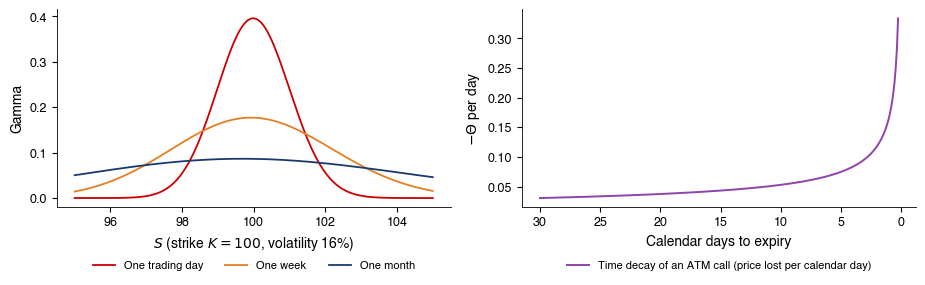

{'g1': 0.39580824686081534,
 'g21': 0.08635050749532194,
 'ratio': 4.583739671504054,
 'th1': 0.167051282070237,
 'th30': 0.030491498472023242}

In [26]:
def fig_0dte_gamma():
    S = np.linspace(95, 105, 401)
    fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.0))
    for T, c, lab in [(1 / 252, IDAred, 'One trading day'), (5 / 252, Orange, 'One week'), (21 / 252, MainBlue, 'One month')]:
        g = bs_greeks(S, 100, T, 0.0, 0.16, 'call')
        axes[0].plot(S, g['gamma'], color=c, lw=1.3, label=lab)
    axes[0].set_xlabel('$S$ (strike $K = 100$, volatility 16%)'); axes[0].set_ylabel('Gamma')
    legend_outside_bottom(axes[0], ncol=3, y=-0.22)
    days = np.linspace(0.25, 30, 300)
    th = -bs_greeks(100, 100, days / 365, 0.0, 0.16, 'call')['theta']
    axes[1].plot(days, th, color=Purple, lw=1.4, label='Time decay of an ATM call (price lost per calendar day)')
    axes[1].set_xlabel('Calendar days to expiry'); axes[1].set_ylabel('$-\\Theta$ per day')
    axes[1].invert_xaxis()
    legend_outside_bottom(axes[1], ncol=1, y=-0.22)
    plt.tight_layout()
    save_fig('ch12_0dte_gamma')
    g1 = float(bs_greeks(100, 100, 1 / 252, 0, 0.16)['gamma']); g21 = float(bs_greeks(100, 100, 21 / 252, 0, 0.16)['gamma'])
    return dict(g1=g1, g21=g21, ratio=g1 / g21, th1=float(-bs_greeks(100, 100, 1 / 365, 0, 0.16)['theta']),
                th30=float(-bs_greeks(100, 100, 30 / 365, 0, 0.16)['theta']))


fig_0dte_gamma()

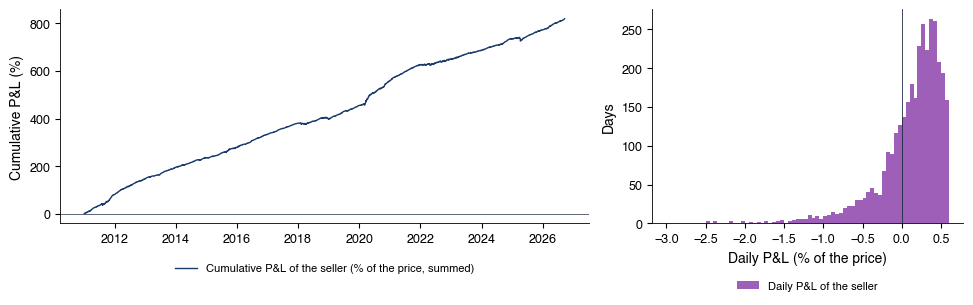

{'phi': 0.7422914918608416,
 'n': 3950,
 'start': '2011-01-04',
 'mean_bp': 20.748717006619096,
 'sd': 0.509620724762208,
 'sharpe': 6.463152994665051,
 'win': 0.7541772151898735,
 'worst': -8.25407434995928,
 'worst_date': '2025-04-09',
 'maxdd': -15.386752844011994,
 'prem': 0.7569761084236172,
 'pay': 0.5494889383574262,
 'skew': -2.0992205092073073,
 'cum': 819.5743217614545,
 'share_big': 0.035443037974683546}

In [27]:
def odte_straddle():
    """Stylised sale of a same-day-expiry ATM straddle on SPY, from open to close (2011-2026).
    Implied volatility of the trading day: previous-day VIX9D, scaled by the share of variance during trading hours
    (estimated on 1993-2010, outside the test period). Premium = sqrt(2/pi) x sigma_day x opening price."""
    oc = spy_open_close()
    adj = load_close('spy')
    cc = np.log(adj).diff()
    oc_r = np.log(oc['close'] / oc['open'])
    both = pd.concat([oc_r.rename('oc'), cc.rename('cc')], axis=1).dropna()
    est = both.loc[:'2010-12-31']
    phi = float((est['oc'] ** 2).sum() / (est['cc'] ** 2).sum())
    v9 = load_close('vix9d').shift(1)
    d = pd.concat([oc, v9.rename('v9')], axis=1, join='inner').dropna().loc['2011-01-04':]
    sig = d['v9'] / 100 * np.sqrt(phi / 252)
    d['prem'] = 100 * np.sqrt(2 / np.pi) * sig
    d['pay'] = 100 * (d['close'] / d['open'] - 1).abs()
    d['pnl'] = d['prem'] - d['pay']
    return d, phi


def fig_0dte_straddle(d, phi):
    fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.2), gridspec_kw={'width_ratios': [1.7, 1]})
    cum = d['pnl'].cumsum()
    axes[0].plot(cum.index, cum.values, color=MainBlue, lw=1.0, label='Cumulative P&L of the seller (% of the price, summed)')
    axes[0].axhline(0, color=Gray, lw=0.5)
    axes[0].set_ylabel('Cumulative P&L (%)')
    legend_outside_bottom(axes[0], ncol=1, y=-0.14)
    axes[1].hist(d['pnl'], bins=np.linspace(-3, 0.6, 73), color=Purple, alpha=0.85, label='Daily P&L of the seller')
    axes[1].axvline(0, color=Gray, lw=0.6)
    axes[1].set_xlabel('Daily P&L (% of the price)'); axes[1].set_ylabel('Days')
    legend_outside_bottom(axes[1], ncol=1, y=-0.22)
    plt.tight_layout()
    save_fig('ch12_0dte_straddle')
    x = d['pnl']
    dd = (cum - cum.cummax()).min()
    w = x.idxmin()
    return dict(phi=phi, n=int(len(x)), start=str(d.index[0].date()), mean_bp=float(100 * x.mean()), sd=float(x.std()),
                sharpe=float(x.mean() / x.std() * np.sqrt(252)), win=float((x > 0).mean()), worst=float(x.min()),
                worst_date=str(w.date()), maxdd=float(dd), prem=float(d['prem'].mean()), pay=float(d['pay'].mean()),
                skew=float(stats.skew(x)), cum=float(cum.iloc[-1]),
                share_big=float((d['pay'] > 2 * d['prem']).mean()))


od, phi = odte_straddle()
fig_0dte_straddle(od, phi)